# Exploración ICS e IPM

Carga de shapefiles desde el repositorio, visualización en mapa y análisis inicial del Índice de Condición Social (ICS) y el Índice de Pobreza Multidimensional (IPM) a nivel de manzana.


In [86]:
# @title 1. Montar Google Drive (opcional, solo en Colab)
import sys
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    print('Google Drive montado')
else:
    print('Ejecutando localmente')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive montado


In [87]:
# @title 2. Instalar dependencias
!pip install geopandas matplotlib mapclassify pyarrow openpyxl pyogrio -q


In [88]:
# @title 3. Clonar el repositorio (solo si es necesario)
import os
import shutil

REPO_URL = 'https://github.com/j0rg3c45/Pobreza_multidimensional_y_condicion_social.git'
REPO_DIR = 'Pobreza_multidimensional_y_condicion_social'

if not os.path.exists(REPO_DIR):
    !git clone {REPO_URL}
else:
    %cd {REPO_DIR}
    !git pull
    %cd ..
print('Repositorio listo')


/content/Pobreza_multidimensional_y_condicion_social
remote: Enumerating objects: 10, done.
remote: Counting objects: 100% (2/2), done.
remote: Total 10 (delta 2), reused 2 (delta 2), pack-reused 8 (from 1)
Unpacking objects: 100% (10/10), 5.27 KiB | 4.00 KiB/s, done.
From https://github.com/j0rg3c45/Pobreza_multidimensional_y_condicion_social
   41dd31c..7874aed  main       -> origin/main
Updating 41dd31c..7874aed
Fast-forward
 .../notebooks_py/01_exploracion_ics_ipm.ipynb      | 352 ++++++++++-----------
 1 file changed, 172 insertions(+), 180 deletions(-)
/content
Repositorio listo


In [89]:
# @title 4. Configuración de Idioma y Estilo Visual
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.patches as mpatches
from pathlib import Path

# Configuración para soporte de caracteres en español y resolución
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.unicode_minus'] = False

# Paleta global accesible para daltónicos
sns.set_palette("colorblind")

print("Entorno configurado: Soporte UTF-8 y paletas accesibles activadas.")
print('Librerías importadas')


Entorno configurado: Soporte UTF-8 y paletas accesibles activadas.
Librerías importadas


In [90]:
# @title 5. Definir rutas maestros
BASE_DIR = REPO_DIR if os.path.exists(REPO_DIR) else '.'
DATA_DIR = os.path.join(BASE_DIR, 'indice_Pobreza', 'data')
EXCEL_PATH = os.path.join(BASE_DIR, 'IPM - Variables (incidencias).xlsx')

# Rutas específicas de GeoJSON
PATH_ICS_GEO = os.path.join(DATA_DIR, 'geojosn_ICS', 'ics_mzn.geojson')
PATH_IPM_GEO = os.path.join(DATA_DIR, 'geojson_ipm', 'Mzn_ipm_variables.geojson')
PATH_ITT_DIR = os.path.join(DATA_DIR, 'geojson_poligonos_territorio_ITT')
PATH_COMUNAS = os.path.join(DATA_DIR, 'geojson_comunas', 'Comunas.geojson')

print(f'Archivo ICS existe: {os.path.exists(PATH_ICS_GEO)}')
print(f'Archivo IPM existe: {os.path.exists(PATH_IPM_GEO)}')
print(f'Excel existe: {os.path.exists(EXCEL_PATH)}')


Archivo ICS existe: True
Archivo IPM existe: True
Excel existe: True


In [91]:
# @title 6. Cargar GeoJSON maestros
gdf_ics = gpd.read_file(PATH_ICS_GEO)
gdf_ipm = gpd.read_file(PATH_IPM_GEO)

# Corrección de seguridad para ICS: 
# Si las coordenadas están en metros (>1000) pero el CRS es EPSG:4326, ajustamos.
if gdf_ics.total_bounds[0] > 1000:
    print('Ajustando CRS de ICS (Metros detectados en archivo con etiqueta geográfica)...')
    CALI_GRID = 'PROJCS["MAGNA-SIRGAS / Cali urban grid",GEOGCS["MAGNA-SIRGAS",DATUM["Marco_Geocentrico_Nacional_de_Referencia",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6686"]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",3.44188333333333],PARAMETER["central_meridian",-76.5205625],PARAMETER["scale_factor",1],PARAMETER["false_easting",1061900.18],PARAMETER["false_northing",872364.63],UNIT["m",1],AXIS["Easting",EAST],AXIS["Northing",NORTH]]'
    gdf_ics.set_crs(CALI_GRID, allow_override=True, inplace=True)
    # Reproyectar a WGS84 para visualización y cruces con IPM
    gdf_ics = gdf_ics.to_crs(epsg=4326)

# Normalizar columnas de IPM para compatibilidad con el resto del notebook
gdf_ipm.columns = [c.lower() for c in gdf_ipm.columns]
cols_incidencia = ['analf_', 'bajo_', 'infancia_', 'inasis_', 'rezago_', 'trab_infan', 'depen_', 'infor_', 'salud_', 'asegu_', 'haci_', 'pared_', 'excre_', 'pisos_', 'agua_']
for col in cols_incidencia:
    if col in gdf_ipm.columns:
        gdf_ipm[col + '_val'] = gdf_ipm[col]

# Definir gdf_vars como alias de gdf_ipm (ya contiene geometría y variables)
gdf_vars = gdf_ipm

print(f'ICS: {gdf_ics.shape[0]} geometrías, {gdf_ics.shape[1]} columnas')
print(f'IPM: {gdf_ipm.shape[0]} geometrías, {gdf_ipm.shape[1]} columnas')


ICS: 15658 geometrías, 6 columnas
IPM: 15658 geometrías, 39 columnas


In [92]:
# @title 7. Ver columnas disponibles
print('=== Columnas ICS ===')
print(gdf_ics.columns.tolist())
print()
print('=== Columnas IPM ===')
print(gdf_ipm.columns.tolist())


=== Columnas ICS ===
['COD_MZN', 'CLASE', 'ZONA', 'cod_dane_a', 'ics', 'geometry']

=== Columnas IPM ===
['cod_dpto', 'cod_mpio', 'cod_dane', 'ipm', 'oid_', 'cod_mzn', 'analf_', 'bajo_', 'infancia_', 'inasis_', 'rezago_', 'trab_infan', 'depen_', 'infor_', 'salud_', 'asegu_', 'haci_', 'pared_', 'excre_', 'pisos_', 'agua_', 'zona', 'zona2', 'geometry', 'analf__val', 'bajo__val', 'infancia__val', 'inasis__val', 'rezago__val', 'trab_infan_val', 'depen__val', 'infor__val', 'salud__val', 'asegu__val', 'haci__val', 'pared__val', 'excre__val', 'pisos__val', 'agua__val']


In [93]:
# @title 8. Vista previa de los datos
print('=== ICS (primeras 5 filas) ===')
display(gdf_ics.head())
print()
print('=== IPM (primeras 5 filas) ===')
display(gdf_ipm.head())


=== ICS (primeras 5 filas) ===


,COD_MZN,CLASE,ZONA,cod_dane_a,ics,geometry
0,7600110000000001010101,1.0,Urbana,7600110000000001010101,32.883636,"MULTIPOLYGON (((-76.5736 3.45369, -76.57297 3...."
1,7600110000000001010102,1.0,Urbana,7600110000000001010102,26.022223,"MULTIPOLYGON (((-76.57208 3.45399, -76.57208 3..."
2,7600110000000001010111,1.0,Urbana,7600110000000001010111,30.111376,"MULTIPOLYGON (((-76.5747 3.45543, -76.57469 3...."
3,7600110000000001010112,1.0,Urbana,7600110000000001010112,29.542585,"MULTIPOLYGON (((-76.57574 3.45462, -76.5759 3...."
4,7600110000000001010113,1.0,Urbana,7600110000000001010113,33.991302,"MULTIPOLYGON (((-76.57596 3.45568, -76.57592 3..."



=== IPM (primeras 5 filas) ===


,cod_dpto,cod_mpio,cod_dane,ipm,oid_,cod_mzn,analf_,bajo_,infancia_,inasis_,...,trab_infan_val,depen__val,infor__val,salud__val,asegu__val,haci__val,pared__val,excre__val,pisos__val,agua__val
0,76,76001,7600110000000001010101,5.7,0,7600110000000001010101,3.2520,34.1463,0.0000,0.0000,...,0.0000,14.6341,86.5854,1.6260,17.8862,7.7236,1.2195,0.0000,0.0000,3.6585
1,76,76001,7600110000000001010102,8.9,1,7600110000000001010102,0.0000,37.7778,0.0000,10.0000,...,3.3333,22.2222,73.3333,4.4444,24.4444,8.8889,0.0000,1.1111,0.0000,0.0000
2,76,76001,7600110000000001010111,6.3,2,7600110000000001010111,7.9365,48.1481,0.0000,0.0000,...,0.0000,14.8148,82.5397,15.3439,12.1693,10.5820,1.5873,0.5291,0.5291,0.5291
3,76,76001,7600110000000001010112,10.5,3,7600110000000001010112,7.3930,30.7393,2.7237,5.4475,...,0.0000,22.9572,77.4319,2.3346,15.1751,10.8949,0.0000,0.0000,0.0000,0.0000
4,76,76001,7600110000000001010113,13.0,4,7600110000000001010113,6.9565,26.9565,5.2174,0.0000,...,0.0000,11.7391,80.8696,0.0000,27.3913,9.5652,0.0000,0.0000,0.0000,0.0000


In [94]:
# @title 9. Sistema de referencia de coordenadas (CRS)
print(f'ICS CRS: {gdf_ics.crs}')
print(f'IPM CRS: {gdf_ipm.crs}')


ICS CRS: EPSG:4326
IPM CRS: EPSG:4326


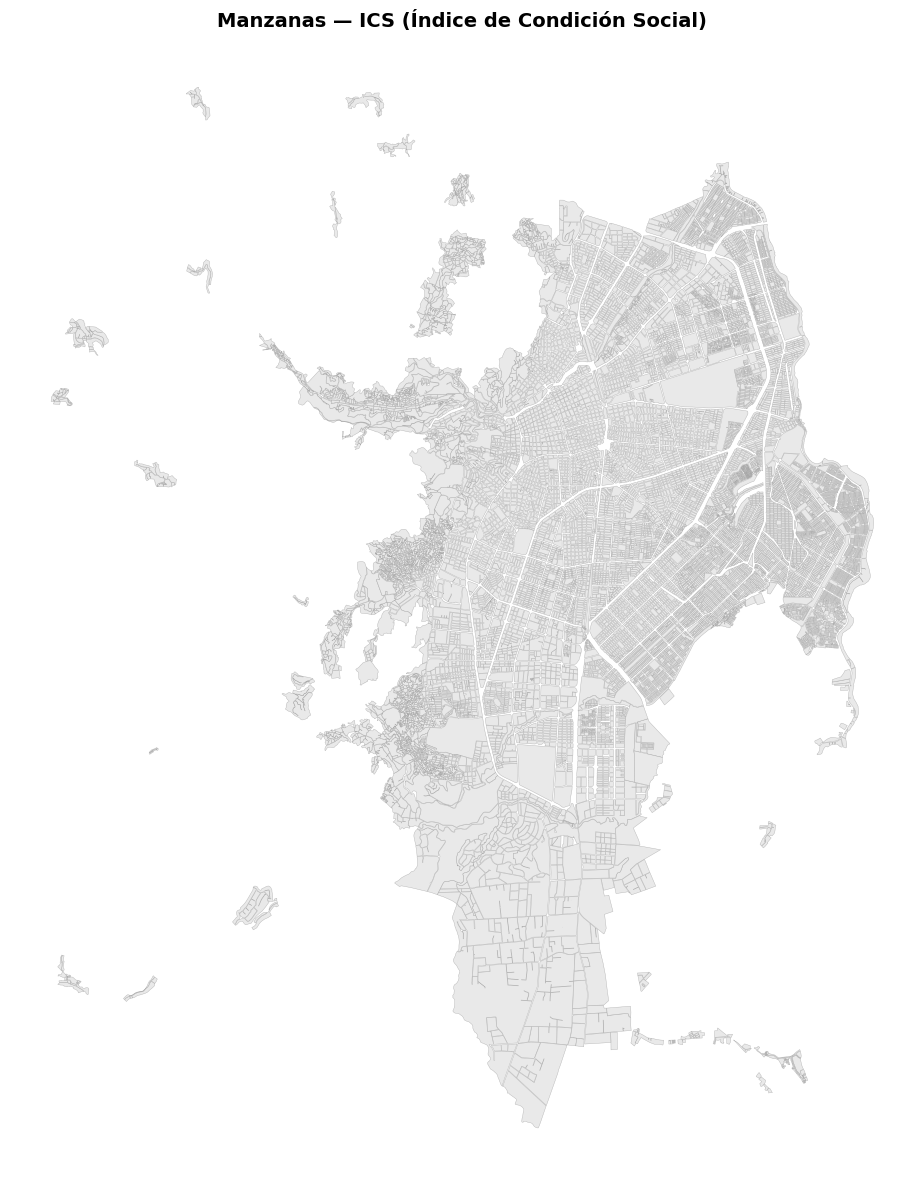

In [95]:
# @title 10. Mapa base — Manzanas ICS
fig, ax = plt.subplots(1, 1, figsize=(14, 12))
gdf_ics.plot(ax=ax, color='#e0e0e0', edgecolor='#999999', linewidth=0.3, alpha=0.7)
ax.set_title('Manzanas — ICS (Índice de Condición Social)', fontsize=14, fontweight='bold')
ax.set_axis_off()
plt.tight_layout()
plt.show()


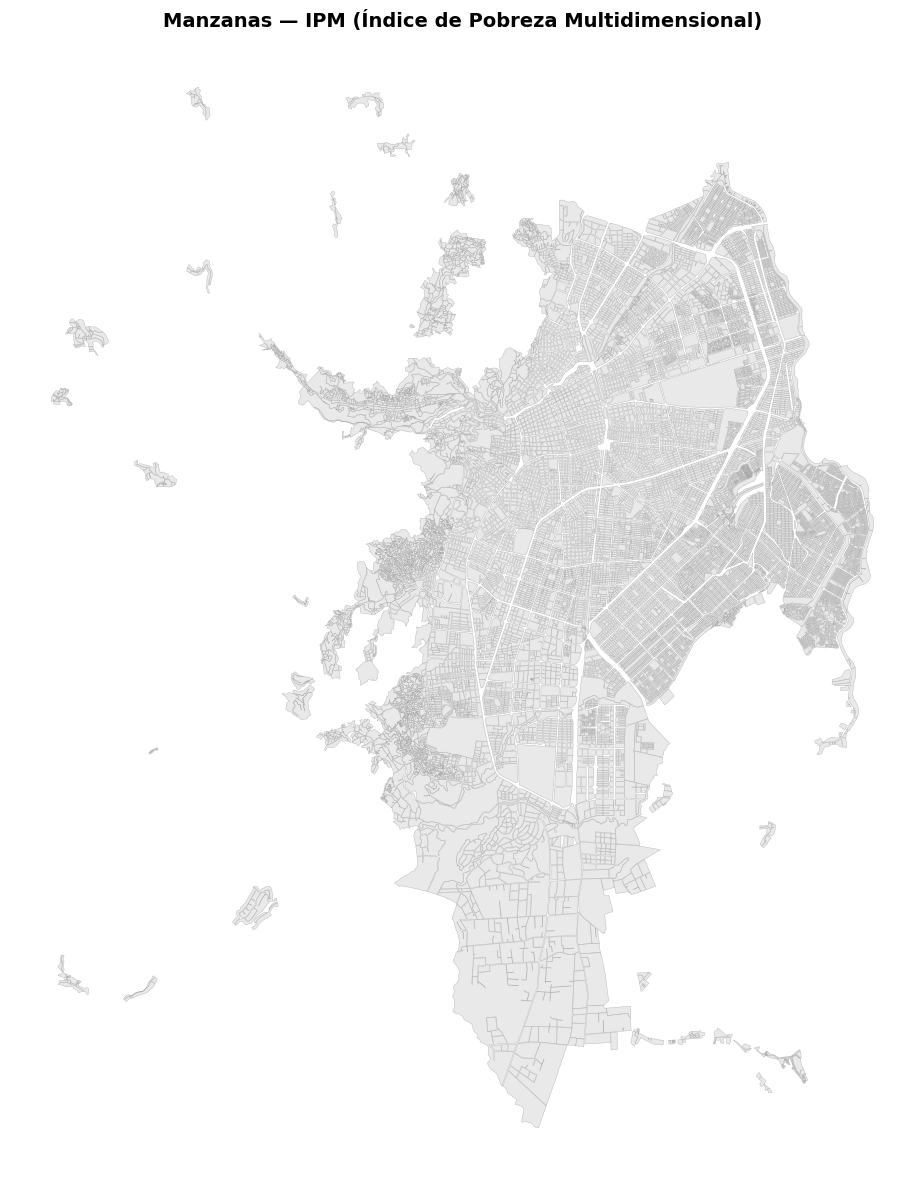

In [96]:
# @title 11. Mapa base — Manzanas IPM
fig, ax = plt.subplots(1, 1, figsize=(14, 12))
gdf_ipm.plot(ax=ax, color='#e0e0e0', edgecolor='#999999', linewidth=0.3, alpha=0.7)
ax.set_title('Manzanas — IPM (Índice de Pobreza Multidimensional)', fontsize=14, fontweight='bold')
ax.set_axis_off()
plt.tight_layout()
plt.show()


In [97]:
# @title 12. Identificar columna de ICS para clasificación
# Buscar columna numérica que contenga el valor del ICS
ics_cols = [c for c in gdf_ics.columns if gdf_ics[c].dtype in ['float64', 'int64']]
print('Columnas numéricas en ICS:', ics_cols)

# Mostrar distribución de las primeras columnas numéricas
for col in ics_cols[:5]:
    print(f'\n{col}:')
    print(gdf_ics[col].describe())


Columnas numéricas en ICS: ['CLASE', 'ics']

CLASE:
count    15658.000000
mean         0.958807
std          0.336837
min          0.000000
25%          1.000000
50%          1.000000
75%          1.000000
max          2.000000
Name: CLASE, dtype: float64

ics:
count    15658.000000
mean        29.804883
std         17.176787
min          0.000000
25%         21.582804
50%         29.552778
75%         39.000000
max        335.050018
Name: ics, dtype: float64


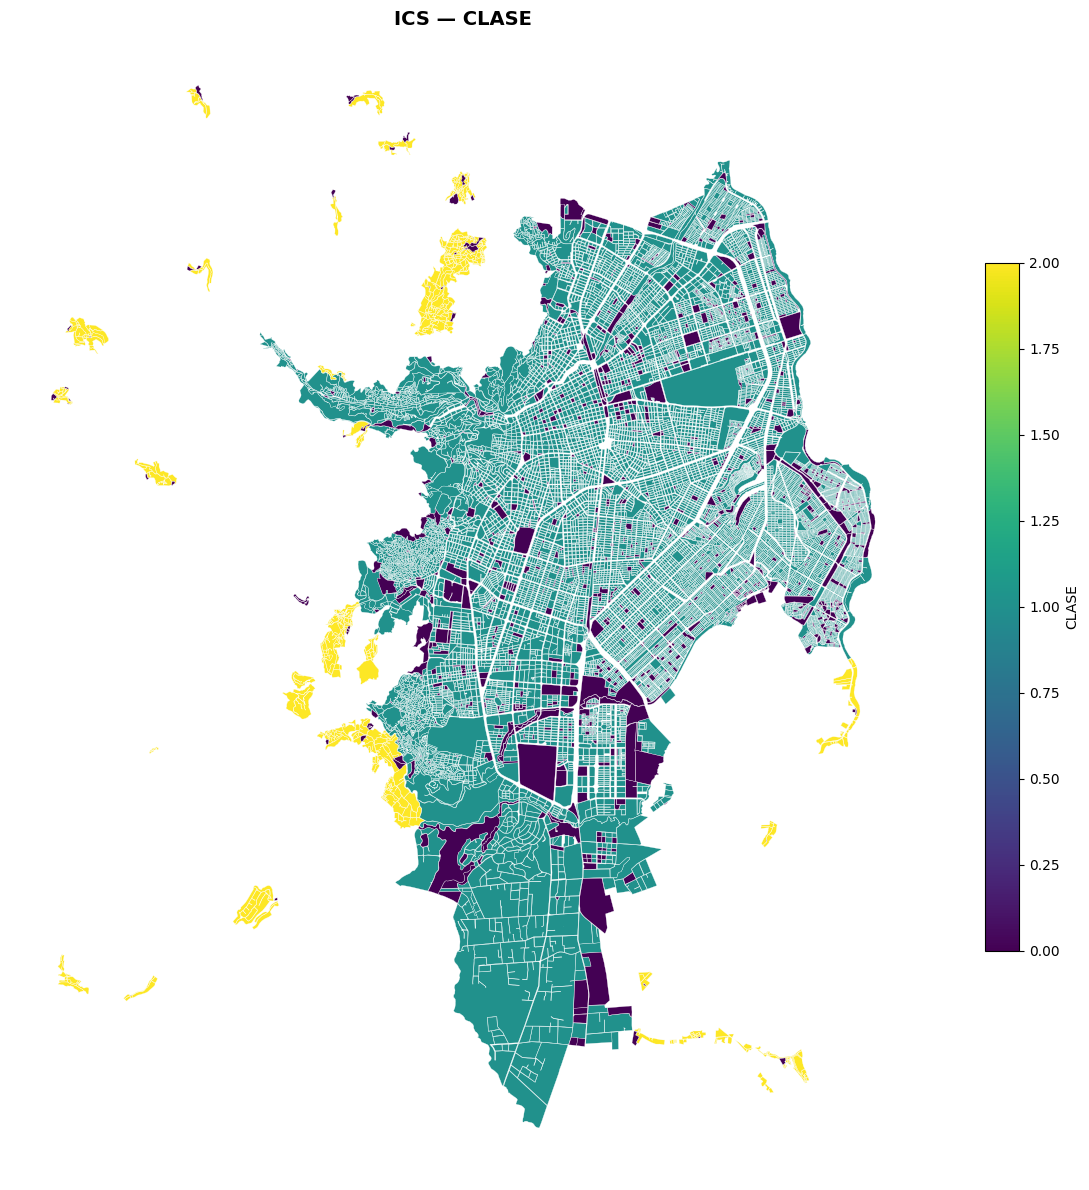

In [98]:
# @title 13. Mapa temático — ICS (si existe columna de valor)
# Identificar columna candidata para mapeo
num_cols_ics = [c for c in gdf_ics.columns if gdf_ics[c].dtype in ['float64', 'int64'] and c.lower() not in ['objectid', 'fid', 'id', 'shape_leng', 'shape_area', 'shape_len', 'shape_le']]

if num_cols_ics:
    col = num_cols_ics[0]
    fig, ax = plt.subplots(1, 1, figsize=(14, 12))
    gdf_ics.plot(column=col, ax=ax, legend=True,
                 cmap='viridis', edgecolor='white', linewidth=0.2,
                 legend_kwds={'label': col, 'shrink': 0.6})
    ax.set_title(f'ICS — {col}', fontsize=14, fontweight='bold')
    ax.set_axis_off()
    plt.tight_layout()
    plt.show()
else:
    print('No se encontró columna numérica para mapear en ICS')


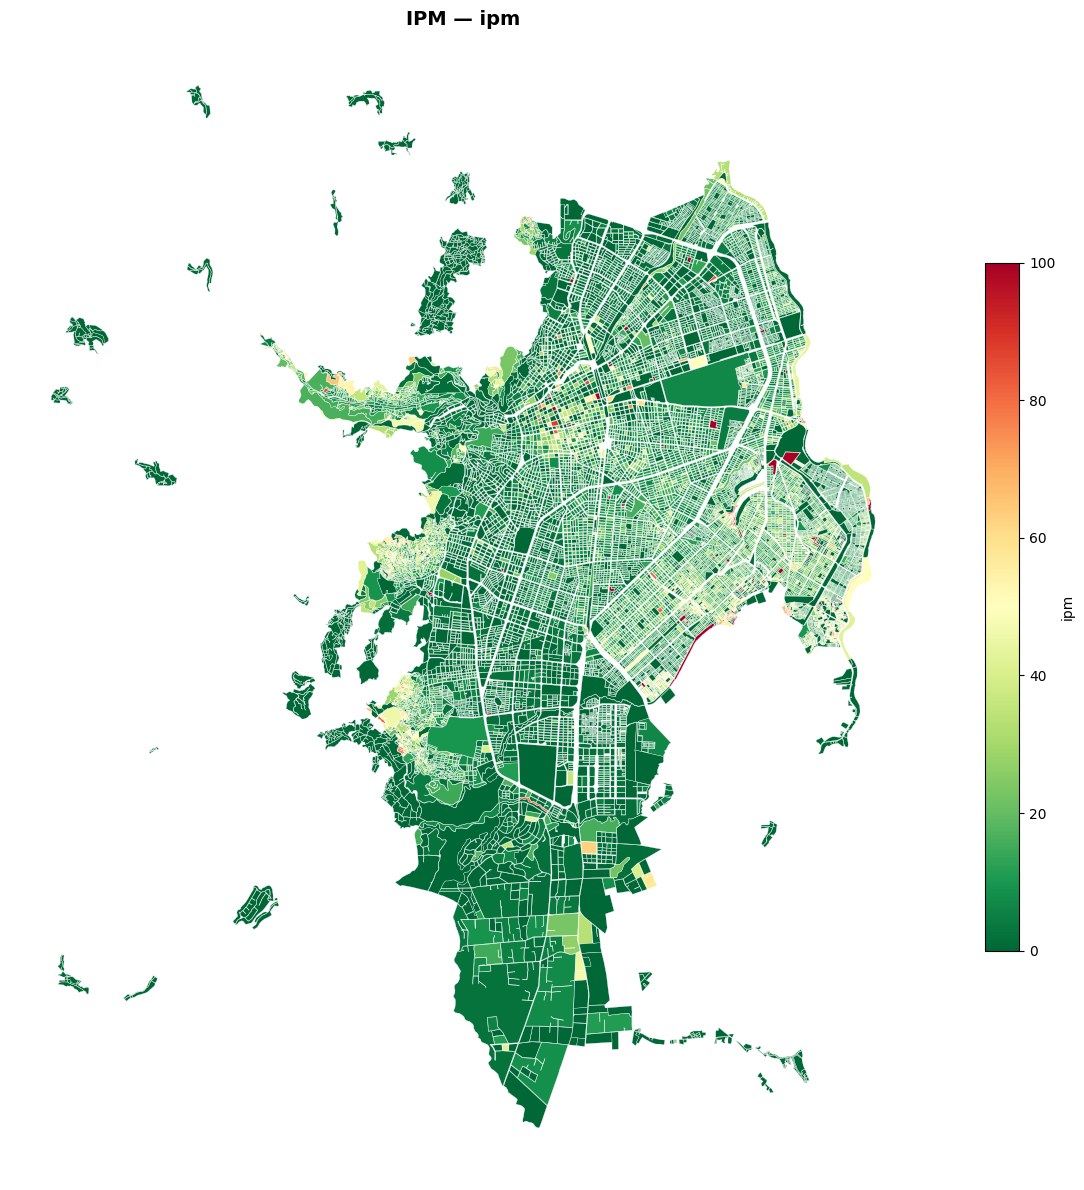

In [99]:
# @title 14. Mapa temático — IPM
num_cols_ipm = [c for c in gdf_ipm.columns if gdf_ipm[c].dtype in ['float64', 'int64'] and c.lower() not in ['objectid', 'fid', 'id', 'shape_leng', 'shape_area', 'shape_len', 'shape_le']]

if num_cols_ipm:
    col = num_cols_ipm[0]
    fig, ax = plt.subplots(1, 1, figsize=(14, 12))
    gdf_ipm.plot(column=col, ax=ax, legend=True,
                 cmap='RdYlGn_r', edgecolor='white', linewidth=0.2,
                 legend_kwds={'label': col, 'shrink': 0.6})
    ax.set_title(f'IPM — {col}', fontsize=14, fontweight='bold')
    ax.set_axis_off()
    plt.tight_layout()
    plt.show()
else:
    print('No se encontró columna numérica para mapear en IPM')


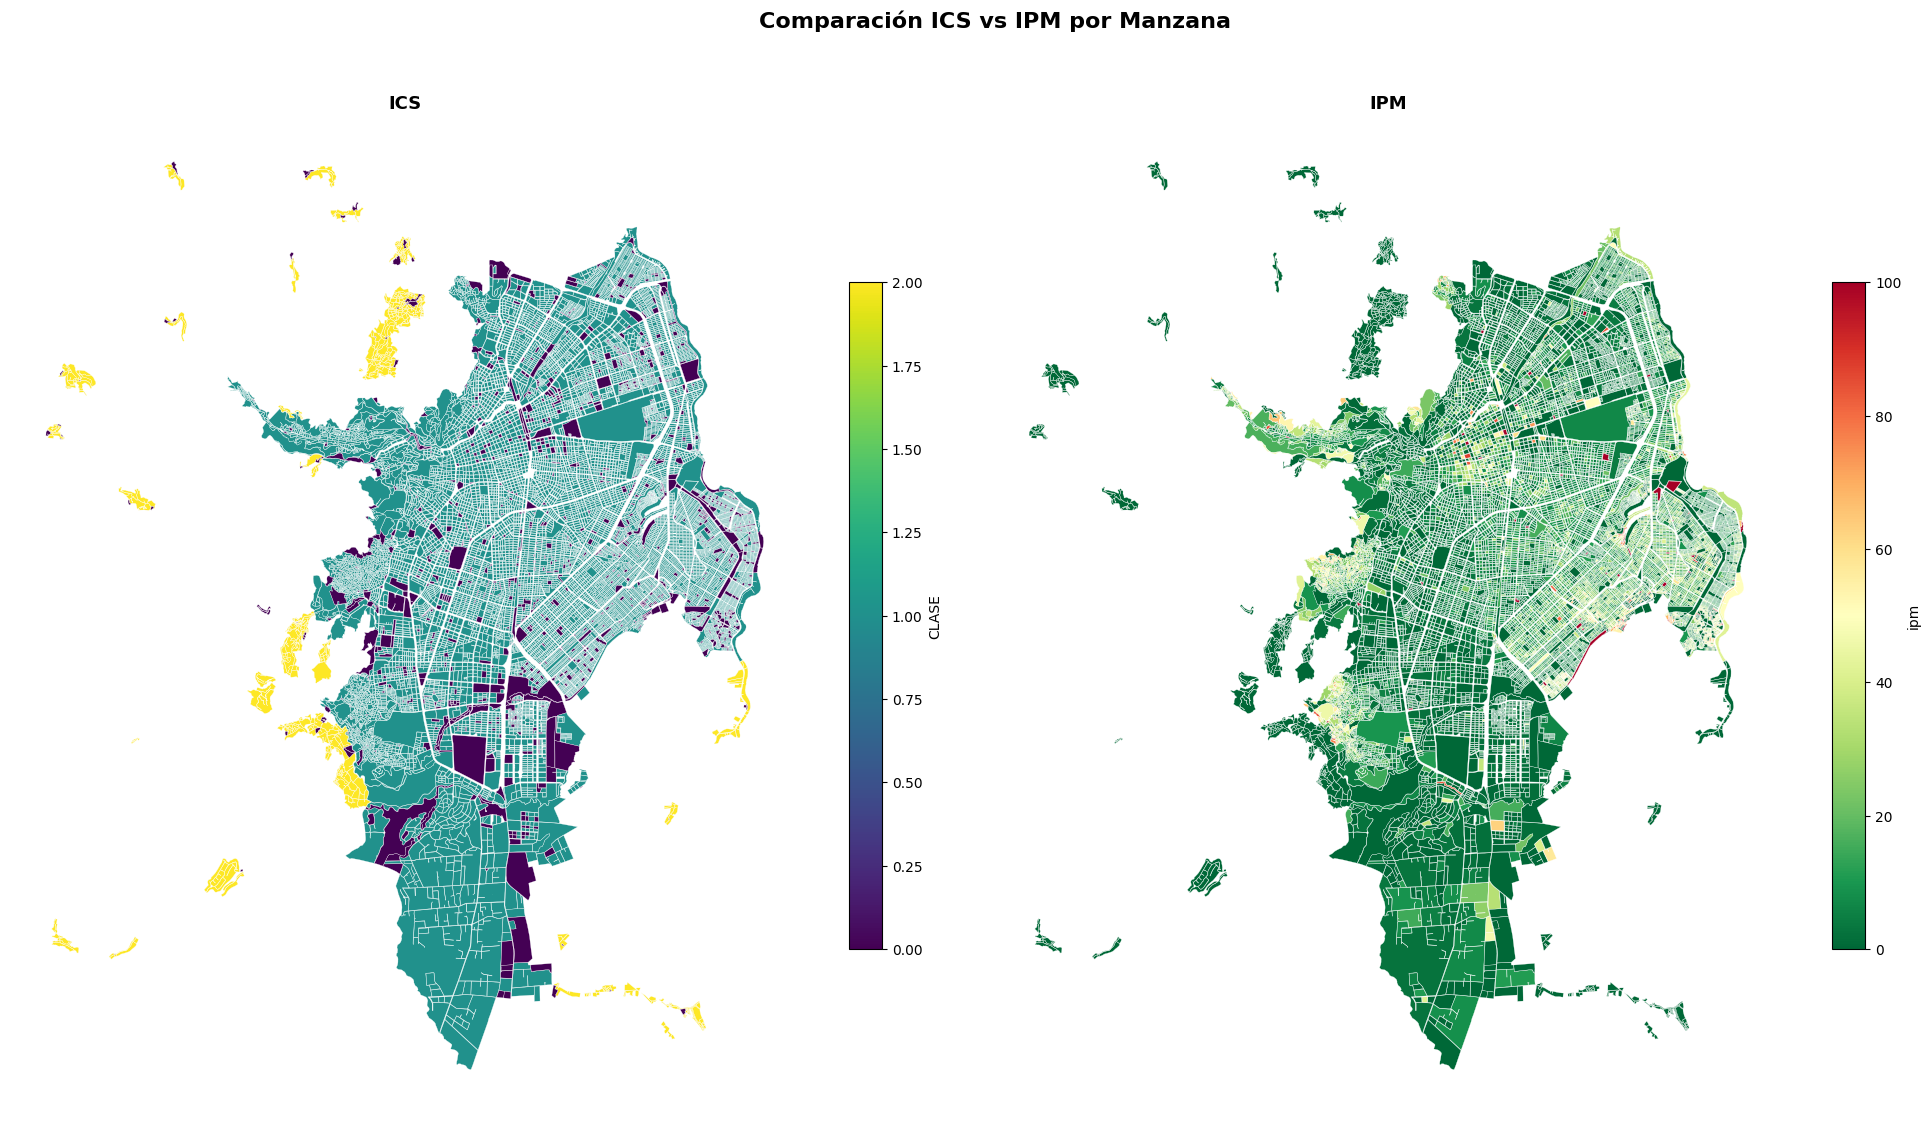

In [100]:
# @title 15. Mapas lado a lado
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 14))

# ICS
if num_cols_ics:
    gdf_ics.plot(column=num_cols_ics[0], ax=ax1, legend=True,
                 cmap='viridis', edgecolor='white', linewidth=0.2,
                 legend_kwds={'label': num_cols_ics[0], 'shrink': 0.5})
    ax1.set_title('ICS', fontsize=13, fontweight='bold')
else:
    gdf_ics.plot(ax=ax1, color='#e0e0e0', edgecolor='#999999', linewidth=0.2)
    ax1.set_title('ICS (sin datos)', fontsize=13, fontweight='bold')
ax1.set_axis_off()

# IPM
if num_cols_ipm:
    gdf_ipm.plot(column=num_cols_ipm[0], ax=ax2, legend=True,
                 cmap='RdYlGn_r', edgecolor='white', linewidth=0.2,
                 legend_kwds={'label': num_cols_ipm[0], 'shrink': 0.5})
    ax2.set_title('IPM', fontsize=13, fontweight='bold')
else:
    gdf_ipm.plot(ax=ax2, color='#e0e0e0', edgecolor='#999999', linewidth=0.2)
    ax2.set_title('IPM (sin datos)', fontsize=13, fontweight='bold')
ax2.set_axis_off()

plt.suptitle('Comparación ICS vs IPM por Manzana', fontsize=16, fontweight='bold', y=0.92)
plt.tight_layout()
plt.show()


In [101]:
# @title 16. Estadísticas descriptivas
print('=== ICS ===')
if num_cols_ics:
    display(gdf_ics[num_cols_ics].describe())

print('\n=== IPM (shapefile) ===')
if num_cols_ipm:
    display(gdf_ipm[num_cols_ipm].describe())

# Diccionario de variables IPM
diccionario = {
    'analf_': 'Analfabetismo',
    'bajo_': 'Bajo logro educativo',
    'infancia_': 'Barreras primera infancia',
    'inasis_': 'Inasistencia escolar',
    'rezago_': 'Rezago escolar',
    'trab_infan_': 'Trabajo infantil',
    'depen_': 'Dependencia económica',
    'infor_': 'Informalidad',
    'salud_': 'Barreras de salud',
    'asegu_': 'Sin aseguramiento en salud',
    'haci_': 'Hacinamiento crítico',
    'pared_': 'Paredes precarias',
    'excre_': 'Eliminación inadecuada de excretas',
    'pisos_': 'Pisos precarios',
    'agua_': 'Sin acceso a agua mejorada'
}

# Cargar variables IPM desde Excel
xls = pd.ExcelFile(EXCEL_PATH)
sheets = [s for s in xls.sheet_names if s != 'Diccionario']
df_ipm_vars = None
for s in sheets:
    df_var = pd.read_excel(xls, s)
    col_name = df_var.columns[1]
    df_var = df_var.rename(columns={col_name: col_name + '_val'})
    df_var.columns = ['cod_mzn', col_name + '_val']
    if df_ipm_vars is None:
        df_ipm_vars = df_var
    else:
        df_ipm_vars = df_ipm_vars.merge(df_var, on='cod_mzn', how='outer')

val_cols = [c for c in df_ipm_vars.columns if c != 'cod_mzn']
print(f'Cargadas {len(val_cols)} variables IPM para {df_ipm_vars.shape[0]} manzanas')

print('\n=== Variables IPM (Excel) - Estadísticas ===')
display(df_ipm_vars[val_cols].describe().round(2))

# Top 5
means = df_ipm_vars[val_cols].mean().sort_values(ascending=False)
print('\n--- Top 5 variables IPM más críticas ---')
for var in means.head().index:
    label = diccionario.get(var.replace('_val',''), var)
    print(f'  {label}: {means[var]:.2f}%')
print(f'\nVariable más crítica: {diccionario.get(means.index[0].replace("_val",""), means.index[0])} ({means.iloc[0]:.2f}%)')


=== ICS ===


,CLASE,ics
count,15658.000000,15658.000000
mean,0.958807,29.804883
std,0.336837,17.176787
min,0.000000,0.000000
25%,1.000000,21.582804
50%,1.000000,29.552778
75%,1.000000,39.000000
max,2.000000,335.050018



=== IPM (shapefile) ===


,ipm,analf_,bajo_,infancia_,inasis_,rezago_,trab_infan,depen_,infor_,salud_,...,trab_infan_val,depen__val,infor__val,salud__val,asegu__val,haci__val,pared__val,excre__val,pisos__val,agua__val
count,15658.000000,15658.000000,15658.000000,15658.000000,15658.000000,15658.000000,15658.000000,15658.000000,15658.000000,15658.000000,...,15658.000000,15658.000000,15658.000000,15658.000000,15658.000000,15658.000000,15658.000000,15658.000000,15658.000000,15658.000000
mean,11.691155,5.323659,31.614810,2.536535,3.892774,15.050798,0.795583,20.617596,71.284840,4.144026,...,0.795583,20.617596,71.284840,4.144026,18.730301,6.850543,0.840873,1.895432,0.430567,1.189167
std,14.733710,7.354803,23.431274,4.504190,6.590420,13.549174,2.683144,14.703059,29.337391,6.877965,...,2.683144,14.703059,29.337391,6.877965,12.264133,9.746928,4.837802,9.700233,2.796260,7.216322
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,11.363600,0.000000,0.000000,3.636400,0.000000,11.111100,70.895500,0.000000,...,0.000000,11.111100,70.895500,0.000000,11.023600,0.000000,0.000000,0.000000,0.000000,0.000000
50%,7.200000,2.792600,30.188700,0.000000,0.000000,12.903200,0.000000,19.613200,81.481500,0.597900,...,0.000000,19.613200,81.481500,0.597900,19.178100,3.092800,0.000000,0.000000,0.000000,0.000000
75%,17.100000,8.017650,48.780500,3.894850,5.633800,22.857100,0.000000,28.695700,88.235300,5.952400,...,0.000000,28.695700,88.235300,5.952400,26.427675,10.253775,0.000000,0.000000,0.000000,0.000000
max,100.000000,100.000000,100.000000,66.666700,80.000000,100.000000,80.000000,100.000000,100.000000,100.000000,...,80.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,80.000000,100.000000


Cargadas 15 variables IPM para 13687 manzanas

=== Variables IPM (Excel) - Estadísticas ===


,analf__val,bajo__val,infancia__val,inasis__val,rezago__val,trab_infan__val,depen__val,infor__val,salud__val,asegu__val,haci__val,pared__val,excre__val,pisos__val,agua__val
count,9512.00,13484.00,6487.00,7435.00,12210.00,2662.00,13415.00,13686.00,7932.00,13187.00,9228.00,1425.00,2008.00,1065.00,1511.00
mean,8.87,37.02,6.15,8.24,19.41,4.70,24.20,81.99,8.22,22.32,11.67,9.40,14.94,6.52,13.50
std,7.70,21.15,5.20,7.49,12.35,4.91,12.93,10.64,7.76,9.94,10.27,13.37,23.29,8.79,20.45
min,0.17,0.55,0.27,0.32,1.04,0.09,0.59,9.52,0.14,1.01,0.16,0.10,0.05,0.11,0.14
25%,3.70,19.88,2.86,3.42,10.05,1.99,15.28,76.19,3.12,15.56,4.52,1.74,1.68,1.56,1.71
50%,6.67,35.48,4.76,5.98,16.95,3.37,22.22,83.33,5.88,21.43,8.70,4.55,4.26,3.37,4.55
75%,11.65,51.95,7.69,10.34,26.03,5.67,30.59,89.19,10.78,27.84,15.50,11.11,16.07,7.79,14.91
max,100.00,100.00,66.67,80.00,100.00,80.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,80.00,100.00



--- Top 5 variables IPM más críticas ---
  Informalidad: 81.99%
  Bajo logro educativo: 37.02%
  Dependencia económica: 24.20%
  Sin aseguramiento en salud: 22.32%
  Rezago escolar: 19.41%

Variable más crítica: Informalidad (81.99%)


## Enriquecimiento geoespacial: Comunas y zonas de interés


In [102]:
# @title 17. Cargar GeoJSONs auxiliares (comunas, ITT territories)
gdf_comunas = gpd.read_file(PATH_COMUNAS)
print(f'Comunas: {gdf_comunas.shape[0]} geometrías')

# Cargar polígonos ITT dinámicamente
import glob
itt_files = glob.glob(os.path.join(PATH_ITT_DIR, 'poligono_*.geojson'))
gdf_itt = {}
for f in itt_files:
    name = os.path.basename(f).replace('poligono_', '').replace('.geojson', '').replace('_Buffer_100', '')
    gdf_itt[name] = gpd.read_file(f)
    print(f'Cargado {name}: {gdf_itt[name].shape[0]} geometrías')

# Asignar específicamente para compatibilidad con celdas posteriores
gdf_obrero = gdf_itt.get('Barrio_Obrero')
gdf_roosevelt = gdf_itt.get('Roosevelt')
gdf_oriente = gdf_itt.get('Oriente')


Comunas: 22 geometrías
Cargado ciudad_de_cali_T5: 1 geometrías
Cargado ciudad_de_cali_T3: 1 geometrías
Cargado ciudad_de_cali_T8: 1 geometrías
Cargado Barrio_Obrero: 1 geometrías
Cargado Roosevelt: 1 geometrías
Cargado ciudad_de_cali_T6: 1 geometrías
Cargado ciudad_de_cali_T1: 1 geometrías
Cargado ciudad_de_cali_T7: 1 geometrías
Cargado ciudad_de_cali_T4: 1 geometrías
Cargado ciudad_de_cali_T2: 1 geometrías
Cargado Oriente: 5 geometrías


In [103]:
# @title 18. Unificar CRS y asignar comuna por spatial join
crs_ref = gdf_ics.crs
print(f'CRS de referencia (ICS): {crs_ref}')

gdf_comunas_proj = gdf_comunas.to_crs(crs_ref)
gdf_ipm_proj = gdf_ipm.to_crs(crs_ref)

gdf_ics_con_comuna = gpd.sjoin(gdf_ics, gdf_comunas_proj[['comuna', 'nombre', 'geometry']], how='left', predicate='intersects')
gdf_ipm_con_comuna = gpd.sjoin(gdf_ipm_proj, gdf_comunas_proj[['comuna', 'nombre', 'geometry']], how='left', predicate='intersects')

comunas_ics = gdf_ics_con_comuna['comuna'].notna().sum()
comunas_ipm = gdf_ipm_con_comuna['comuna'].notna().sum()
print(f'Manzanas ICS con comuna asignada: {comunas_ics} / {len(gdf_ics_con_comuna)}')
print(f'Manzanas IPM con comuna asignada: {comunas_ipm} / {len(gdf_ipm_con_comuna)}')


CRS de referencia (ICS): EPSG:4326
Manzanas ICS con comuna asignada: 14629 / 15730
Manzanas IPM con comuna asignada: 14629 / 15730


In [104]:
# @title 19. Vista previa con comuna asignada
print('=== ICS con comuna ===')
display(gdf_ics_con_comuna.drop(columns='index_right', errors='ignore').head())

print('\n=== IPM con comuna ===')
display(gdf_ipm_con_comuna.drop(columns='index_right', errors='ignore').head())


=== ICS con comuna ===


,COD_MZN,CLASE,ZONA,cod_dane_a,ics,geometry,comuna,nombre
0,7600110000000001010101,1.0,Urbana,7600110000000001010101,32.883636,"MULTIPOLYGON (((-76.5736 3.45369, -76.57297 3....",1.0,Comuna 1
1,7600110000000001010102,1.0,Urbana,7600110000000001010102,26.022223,"MULTIPOLYGON (((-76.57208 3.45399, -76.57208 3...",1.0,Comuna 1
2,7600110000000001010111,1.0,Urbana,7600110000000001010111,30.111376,"MULTIPOLYGON (((-76.5747 3.45543, -76.57469 3....",1.0,Comuna 1
3,7600110000000001010112,1.0,Urbana,7600110000000001010112,29.542585,"MULTIPOLYGON (((-76.57574 3.45462, -76.5759 3....",1.0,Comuna 1
4,7600110000000001010113,1.0,Urbana,7600110000000001010113,33.991302,"MULTIPOLYGON (((-76.57596 3.45568, -76.57592 3...",1.0,Comuna 1



=== IPM con comuna ===


,cod_dpto,cod_mpio,cod_dane,ipm,oid_,cod_mzn,analf_,bajo_,infancia_,inasis_,...,infor__val,salud__val,asegu__val,haci__val,pared__val,excre__val,pisos__val,agua__val,comuna,nombre
0,76,76001,7600110000000001010101,5.7,0,7600110000000001010101,3.2520,34.1463,0.0000,0.0000,...,86.5854,1.6260,17.8862,7.7236,1.2195,0.0000,0.0000,3.6585,1.0,Comuna 1
1,76,76001,7600110000000001010102,8.9,1,7600110000000001010102,0.0000,37.7778,0.0000,10.0000,...,73.3333,4.4444,24.4444,8.8889,0.0000,1.1111,0.0000,0.0000,1.0,Comuna 1
2,76,76001,7600110000000001010111,6.3,2,7600110000000001010111,7.9365,48.1481,0.0000,0.0000,...,82.5397,15.3439,12.1693,10.5820,1.5873,0.5291,0.5291,0.5291,1.0,Comuna 1
3,76,76001,7600110000000001010112,10.5,3,7600110000000001010112,7.3930,30.7393,2.7237,5.4475,...,77.4319,2.3346,15.1751,10.8949,0.0000,0.0000,0.0000,0.0000,1.0,Comuna 1
4,76,76001,7600110000000001010113,13.0,4,7600110000000001010113,6.9565,26.9565,5.2174,0.0000,...,80.8696,0.0000,27.3913,9.5652,0.0000,0.0000,0.0000,0.0000,1.0,Comuna 1


In [105]:
# @title 20. Estadísticas de ICS, IPM y variables por comuna
print('=== ICS promedio por comuna ===')
ics_por_comuna = gdf_ics_con_comuna.groupby('nombre').agg(
    manzanas=('cod_dane_a', 'count'),
    ics_promedio=('ics', 'mean'),
    ics_min=('ics', 'min'),
    ics_max=('ics', 'max')
).round(2).sort_values('ics_promedio', ascending=False)
display(ics_por_comuna)

print('=== IPM global promedio por comuna ===')
ipm_por_comuna = gdf_ipm_con_comuna.groupby('nombre').agg(
    manzanas=('cod_dane', 'count'),
    ipm_promedio=('ipm', 'mean'),
    ipm_min=('ipm', 'min'),
    ipm_max=('ipm', 'max')
).round(2).sort_values('ipm_promedio')
display(ipm_por_comuna)

# Merge Excel vars con ICS para obtener geometrías
# Clave: quitar los 2 dígitos de comuna del código Excel
df_ipm_vars['COD_MZN'] = df_ipm_vars['cod_mzn'].astype(str).str[:6] + df_ipm_vars['cod_mzn'].astype(str).str[8:]

df_vars_geom = gdf_ics[['COD_MZN', 'geometry']].merge(
    df_ipm_vars, on='COD_MZN', how='inner')
gdf_vars = gpd.GeoDataFrame(df_vars_geom, crs=gdf_ics.crs)
print(f'\nMerge Excel+ICS: {len(gdf_vars)}/{len(df_ipm_vars)} manzanas con geometría')

# Spatial join con comunas
gdf_vars_comuna = gpd.sjoin(gdf_vars, gdf_comunas_proj[['comuna', 'nombre', 'geometry']],
                             how='left', predicate='intersects')

# Top 3 variables IPM por comuna
print('\n=== Top 3 variables IPM por comuna ===')
comuna_stats = gdf_vars_comuna.groupby('nombre')[val_cols].mean().round(2)
top3_vars = means.head(3).index.tolist()
for var in top3_vars:
    label = diccionario.get(var.replace('_val',''), var)
    df_show = comuna_stats[var].sort_values(ascending=False).head(5).to_frame(label)
    print(f'\n{label} (top 5 comunas):')
    display(df_show)


=== ICS promedio por comuna ===


,manzanas,ics_promedio,ics_min,ics_max
nombre,,,,
Comuna 22,148,59.81,0.0,153.31
Comuna 19,685,44.42,0.0,97.10
Comuna 2,812,43.72,0.0,99.06
Comuna 17,760,43.58,0.0,98.00
Comuna 5,561,35.60,0.0,62.94
Comuna 10,551,34.84,0.0,75.46
Comuna 8,580,32.44,0.0,108.13
Comuna 12,323,31.43,0.0,87.28
Comuna 16,515,30.79,0.0,83.93


=== IPM global promedio por comuna ===


,manzanas,ipm_promedio,ipm_min,ipm_max
nombre,,,,
Comuna 17,892,3.35,0.0,100.0
Comuna 19,798,3.55,0.0,100.0
Comuna 22,171,4.35,0.0,83.3
Comuna 2,937,4.50,0.0,100.0
Comuna 5,635,4.80,0.0,83.3
Comuna 10,620,6.17,0.0,70.7
Comuna 8,642,8.53,0.0,100.0
Comuna 6,894,8.90,0.0,100.0
Comuna 4,545,9.21,0.0,100.0



Merge Excel+ICS: 13614/13687 manzanas con geometría

=== Top 3 variables IPM por comuna ===

Informalidad (top 5 comunas):


,Informalidad
nombre,
Comuna 20,87.66
Comuna 9,87.04
Comuna 15,86.98
Comuna 13,86.68
Comuna 14,86.51



Bajo logro educativo (top 5 comunas):


,Bajo logro educativo
nombre,
Comuna 20,61.76
Comuna 14,51.87
Comuna 1,49.17
Comuna 13,48.61
Comuna 15,46.33



Dependencia económica (top 5 comunas):


,Dependencia económica
nombre,
Comuna 15,31.36
Comuna 14,30.82
Comuna 21,30.56
Comuna 13,28.87
Comuna 20,28.22


In [106]:
# @title 21. Identificar manzanas en todas las zonas ITT (Dinámico)
gdf_itt_proj = {}
for name, poly in gdf_itt.items():
    # Proyectar al CRS de referencia (ICS)
    gdf_itt_proj[name] = poly.to_crs(crs_ref)
    
    # Identificar manzanas dentro de la zona (en ICS e IPM)
    col_name = f'en_{name.lower()}'
    
    # Usar .index.isin() para evitar errores de reindexación con duplicados en el join
    join_ics = gpd.sjoin(gdf_ics, gdf_itt_proj[name], how='inner', predicate='intersects')
    gdf_ics[col_name] = gdf_ics.index.isin(join_ics.index)
    
    join_ipm = gpd.sjoin(gdf_ipm_proj, gdf_itt_proj[name], how='inner', predicate='intersects')
    gdf_ipm[col_name] = gdf_ipm.index.isin(join_ipm.index)
    
    count = gdf_ics[col_name].sum()
    print(f'Zona {name:.<30} {count} manzanas encontradas')

# Alias para compatibilidad con celdas antiguas
gdf_obrero_proj = gdf_itt_proj.get('Barrio_Obrero')
gdf_roosevelt_proj = gdf_itt_proj.get('Roosevelt')


Zona ciudad_de_cali_T5............. 83 manzanas encontradas
Zona ciudad_de_cali_T3............. 99 manzanas encontradas
Zona ciudad_de_cali_T8............. 5 manzanas encontradas
Zona Barrio_Obrero................. 45 manzanas encontradas
Zona Roosevelt..................... 41 manzanas encontradas
Zona ciudad_de_cali_T6............. 117 manzanas encontradas
Zona ciudad_de_cali_T1............. 44 manzanas encontradas
Zona ciudad_de_cali_T7............. 93 manzanas encontradas
Zona ciudad_de_cali_T4............. 122 manzanas encontradas
Zona ciudad_de_cali_T2............. 45 manzanas encontradas
Zona Oriente....................... 1092 manzanas encontradas


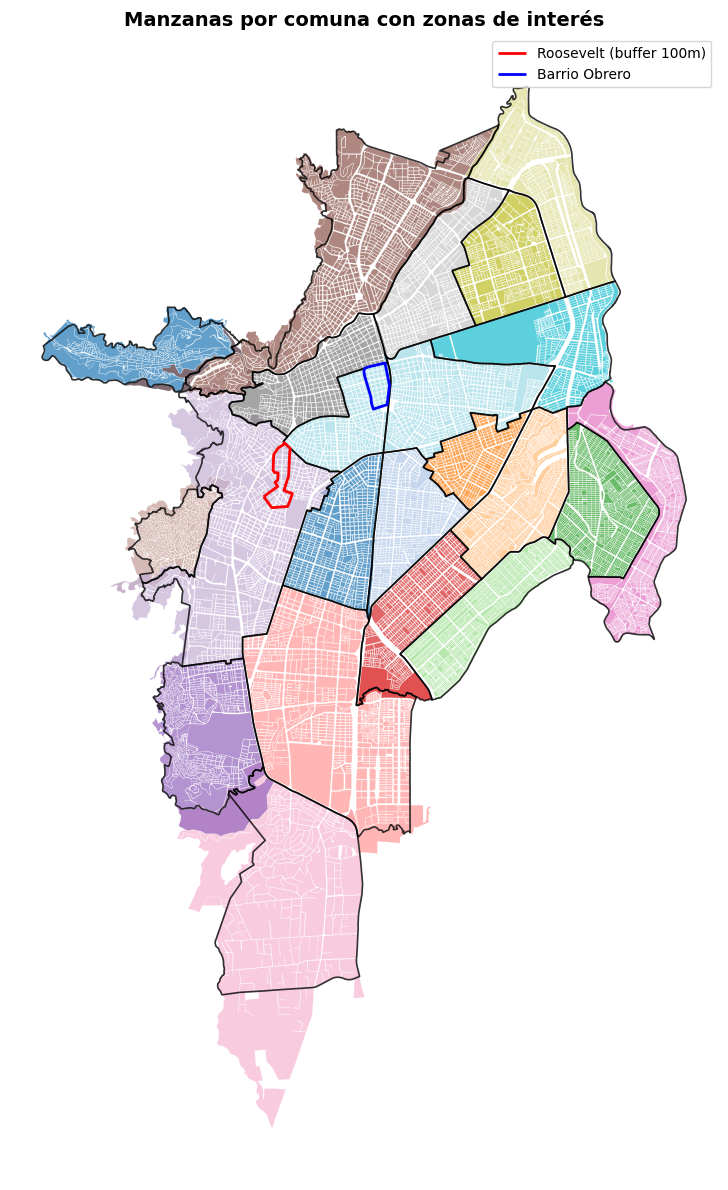

In [107]:
# @title 22. Mapa - Manzanas por comuna con zonas de inter\u00e9s
fig, ax = plt.subplots(1, 1, figsize=(14, 12))

gdf_ics_con_comuna.plot(column='nombre', ax=ax, legend=True,
                         cmap='tab20', edgecolor='white', linewidth=0.1, alpha=0.7,
                         legend_kwds={'title': 'Comuna', 'loc': 'upper left', 'fontsize': 8})

gdf_comunas_proj.boundary.plot(ax=ax, color='black', linewidth=1.2, alpha=0.8)
gdf_roosevelt_proj.boundary.plot(ax=ax, color='red', linewidth=2, label='Roosevelt (buffer 100m)')
gdf_obrero_proj.boundary.plot(ax=ax, color='blue', linewidth=2, label='Barrio Obrero')

ax.set_title('Manzanas por comuna con zonas de inter\u00e9s', fontsize=14, fontweight='bold')
ax.set_axis_off()
ax.legend()
plt.tight_layout()
plt.show()


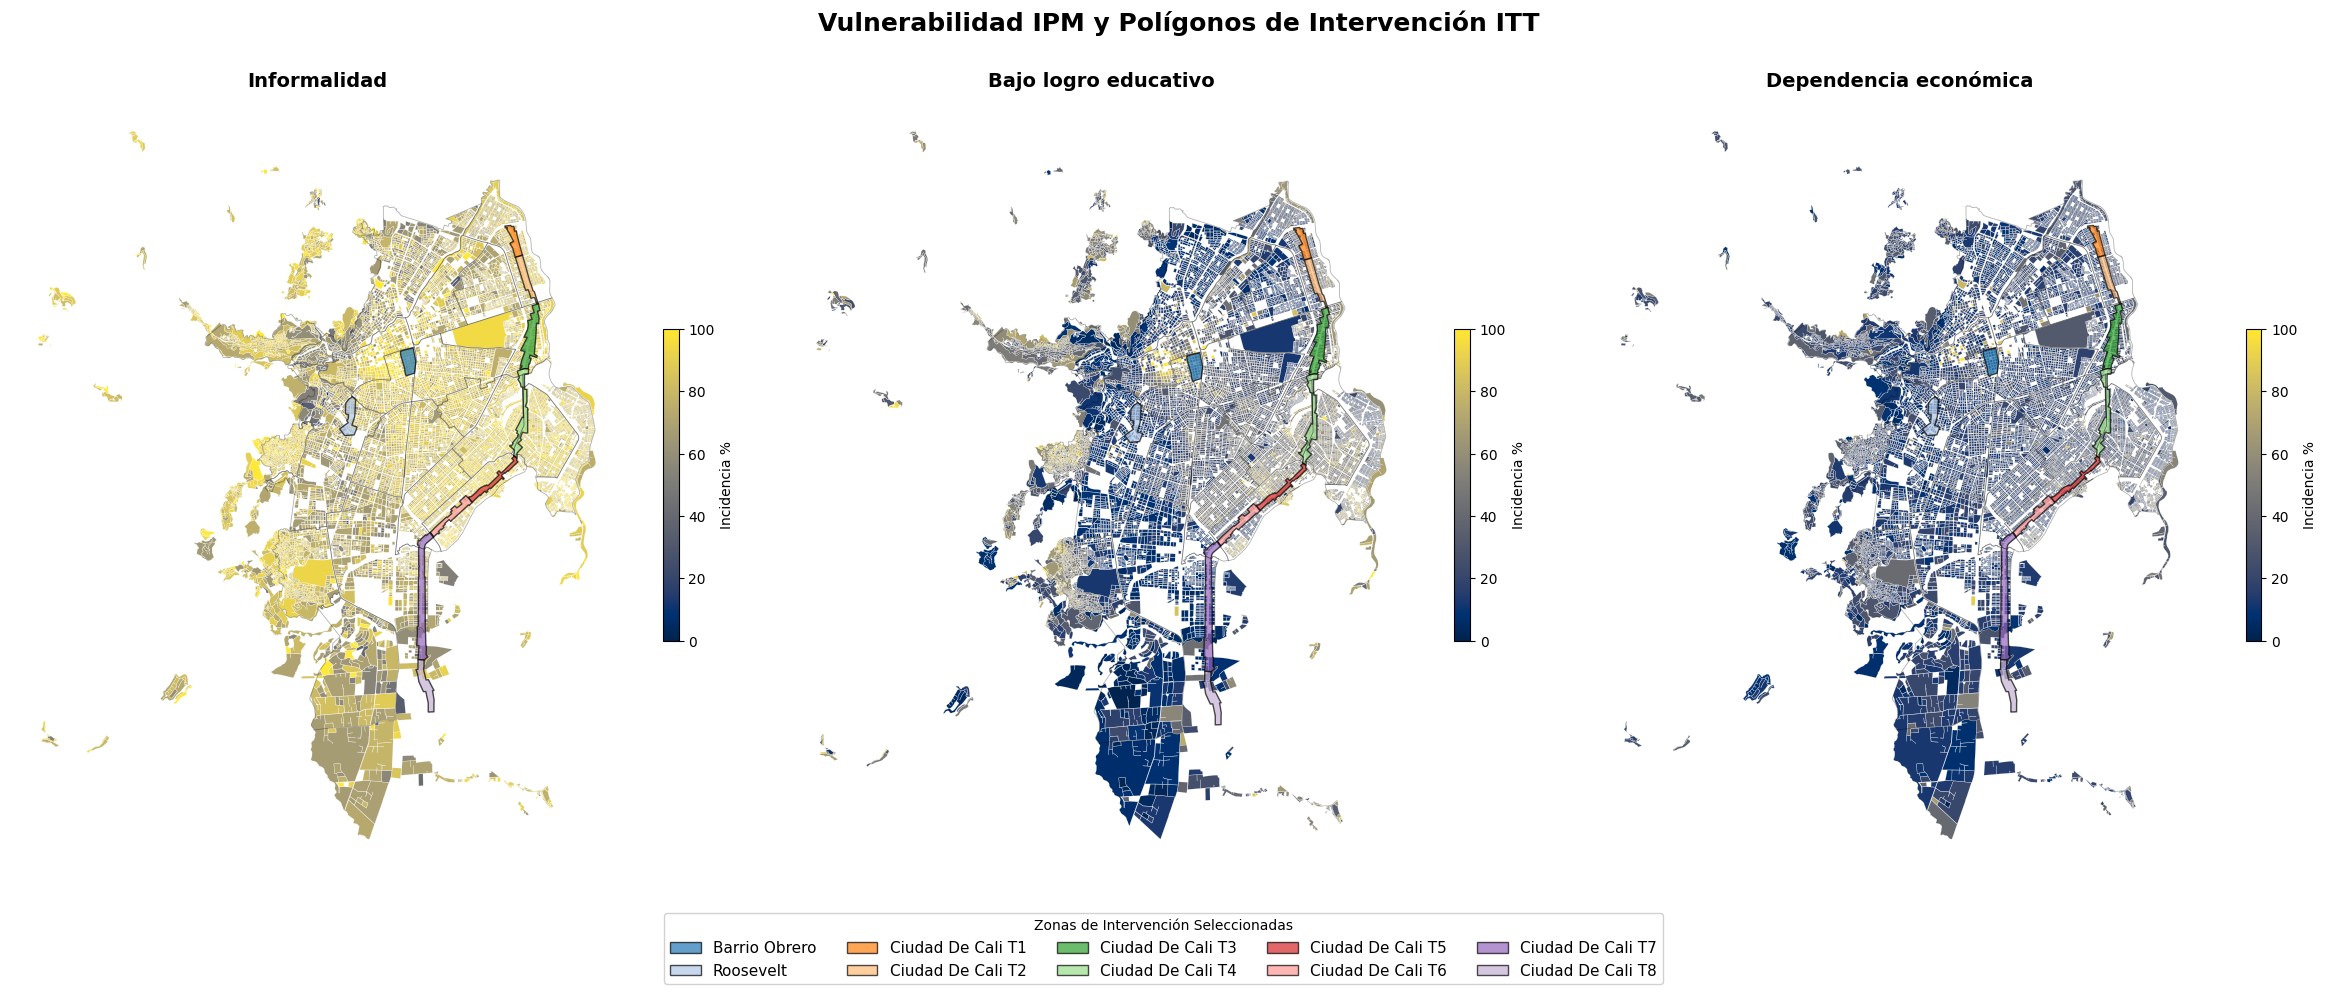

In [108]:
# @title 23. Mapa - Variables IPM más Críticas con Filtro de Tramos
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import geopandas as gpd
import pandas as pd

# --- INICIALIZACIÓN ABSOLUTA DE SEGURIDAD ---
try:
    # Intentamos asegurar que gdf_vars exista y sea un GeoDataFrame
    if 'gdf_vars' not in locals() and 'gdf_vars' not in globals():
        print("Definiendo gdf_vars desde gdf_ipm...")
        gdf_vars = gdf_ipm
    
    # Aseguramos que 'means' tenga datos para el top 3
    if 'means' not in locals() and 'means' not in globals():
        print("Calculando medias de incidencia...")
        inc_cols = [c for c in gdf_vars.columns if c.endswith('_') or c.endswith('_val')]
        means = gdf_vars[inc_cols].mean().sort_values(ascending=False)
        
    # Diccionario básico si falta
    if 'diccionario' not in locals() and 'diccionario' not in globals():
        diccionario = {}
except NameError as e:
    print(f"Error: Los datos maestros no están cargados. Por favor corre la celda 6. Detalle: {e}")
    raise e
# ---------------------------------------------

# -------------------------------------------------------------------------
# AQUÍ PUEDES ACTIVAR O DESACTIVAR LOS POLÍGONOS A MOSTRAR.
# Edita la lista a continuación, quitando o poniendo los nombres de los tramos.
# Nombres disponibles: 'Barrio_Obrero', 'Roosevelt', 'Oriente', 
# 'ciudad_de_cali_T1', 'ciudad_de_cali_T2', ..., 'ciudad_de_cali_T8'
# -------------------------------------------------------------------------
ZONAS_VISIBLES = [
    'Barrio_Obrero', 
    'Roosevelt', 
    'ciudad_de_cali_T1', 
    'ciudad_de_cali_T2', 
    'ciudad_de_cali_T3', 
    'ciudad_de_cali_T4', 
    'ciudad_de_cali_T5', 
    'ciudad_de_cali_T6', 
    'ciudad_de_cali_T7', 
    'ciudad_de_cali_T8'
]

# Mapa de las 3 variables IPM con mayor incidencia
top3_vars = means.head(3).index.tolist()
fig, axes = plt.subplots(1, 3, figsize=(24, 10))

# Paleta de colores optimizada (colorblind friendly)
cmap_tramos = plt.get_cmap('tab20')

for idx_ax, (ax, var) in enumerate(zip(axes, top3_vars)):
    label = diccionario.get(var.replace('_val',''), var)
    
    # Capa base: Variables IPM
    gdf_vars.plot(column=var, ax=ax, legend=True,
                 cmap='cividis', edgecolor='white', linewidth=0.1,
                 legend_kwds={'shrink': 0.4, 'label': 'Incidencia %'},
                 vmin=0, vmax=100)
    
    # Capa 2: Comunas (transparente)
    gdf_comunas_proj.boundary.plot(ax=ax, color='black', linewidth=0.6, alpha=0.3)
    
    # Capa 3: Polígonos ITT Seleccionados (Relleno sólido)
    for i, zona_name in enumerate(ZONAS_VISIBLES):
        if zona_name in gdf_itt:
            color_z = cmap_tramos(i % 20)
            gdf_itt[zona_name].to_crs(gdf_vars.crs).plot(
                ax=ax, color=color_z, alpha=0.7, edgecolor='black', linewidth=1)
            
    ax.set_title(label, fontsize=14, fontweight='bold')
    ax.set_axis_off()

# Leyenda dinámica de zonas
legend_patches = []
for i, zona_name in enumerate(ZONAS_VISIBLES):
    if zona_name in gdf_itt:
        legend_patches.append(Patch(facecolor=cmap_tramos(i % 20), 
                                    edgecolor='black', alpha=0.7, 
                                    label=zona_name.replace('_', ' ').title()))

fig.legend(handles=legend_patches, loc='lower center', ncol=5, 
           fontsize=11, framealpha=0.9, title="Zonas de Intervención Seleccionadas")

plt.suptitle('Vulnerabilidad IPM y Polígonos de Intervención ITT', fontsize=18, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0.1, 1, 0.95])
plt.show()


In [109]:
# @title 24. Filtrar variables IPM por zona
# Spatial join de variables IPM con cada zona de interés
gdf_vars_obrero = gpd.sjoin(gdf_vars, gdf_obrero_proj, how='inner', predicate='intersects')
gdf_vars_roosevelt = gpd.sjoin(gdf_vars, gdf_roosevelt_proj, how='inner', predicate='intersects')

print(f'Manzanas con vars IPM en Barrio Obrero: {len(gdf_vars_obrero)}')
print(f'Manzanas con vars IPM en Roosevelt: {len(gdf_vars_roosevelt)}')

# Promedio por zona
means_obrero = gdf_vars_obrero[val_cols].mean().sort_values(ascending=False)
means_roosevelt = gdf_vars_roosevelt[val_cols].mean().sort_values(ascending=False)

print('\n--- Top 5 Barrio Obrero ---')
for v in means_obrero.head().index:
    lbl = diccionario.get(v.replace('_val',''), v)
    print(f'  {lbl}: {means_obrero[v]:.2f}%')

print('\n--- Top 5 Roosevelt ---')
for v in means_roosevelt.head().index:
    lbl = diccionario.get(v.replace('_val',''), v)
    print(f'  {lbl}: {means_roosevelt[v]:.2f}%')


Manzanas con vars IPM en Barrio Obrero: 43
Manzanas con vars IPM en Roosevelt: 34

--- Top 5 Barrio Obrero ---
  Informalidad: 92.73%
  Bajo logro educativo: 54.19%
  Dependencia económica: 27.05%
  Rezago escolar: 21.13%
  Sin aseguramiento en salud: 19.19%

--- Top 5 Roosevelt ---
  Informalidad: 74.36%
  Trabajo infantil: 31.25%
  Sin aseguramiento en salud: 22.05%
  Dependencia económica: 19.09%
  Bajo logro educativo: 17.58%


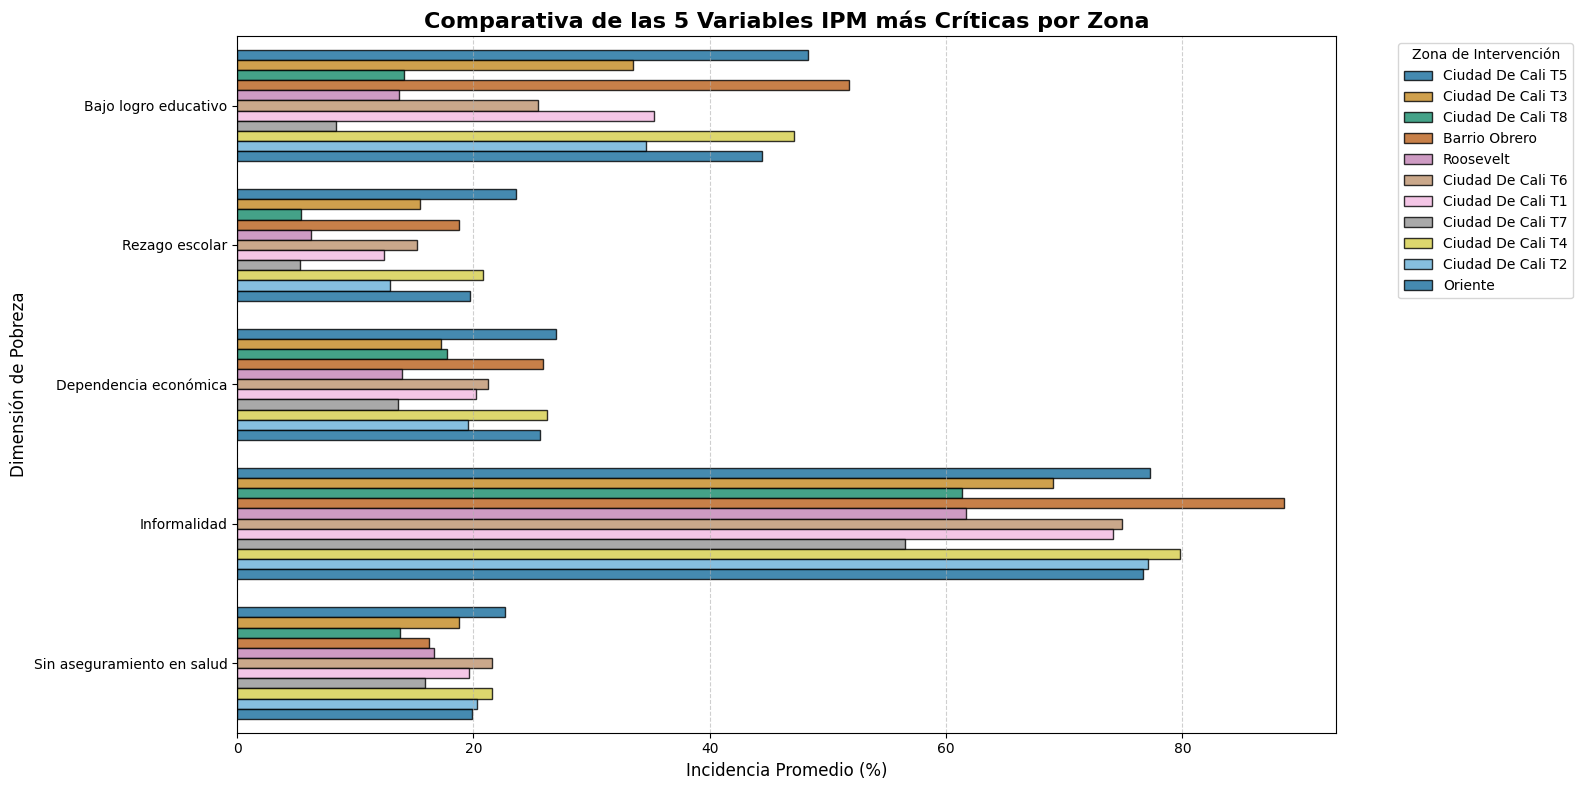

In [110]:
# @title 25. Gráfico - Comparativa Variables IPM por Zona (Top 5)
import seaborn as sns

# Asegurar columnas de valor correctas y diccionario de variables
val_cols = [c for c in gdf_ipm.columns if c.endswith('_val')]
if 'diccionario' not in globals():
    diccionario = {'analf_': 'Analfabetismo', 'bajo_': 'Bajo logro educativo', 'infancia_': 'Cuidado infancia', 'inasis_': 'Inasistencia escolar', 'rezago_': 'Rezago escolar', 'trab_infan': 'Trabajo infantil', 'depen_': 'Dependencia económica', 'infor_': 'Informalidad', 'salud_': 'Barreras salud', 'asegu_': 'Sin aseguramiento salud', 'haci_': 'Hacinamiento', 'pared_': 'Paredes inadecuadas', 'excre_': 'Excretas inadecuadas', 'pisos_': 'Pisos inadecuados', 'agua_': 'Agua no potable'}

# Calcular medias para todas las zonas disponibles
report_data = []
for name, gdf_filt in gdf_ipm_zonas.items():
    if len(gdf_filt) > 0:
        m_zona = gdf_filt[val_cols].mean().to_frame('incidencia')
        m_zona['variable'] = [diccionario.get(v.replace('_val',''), v) for v in m_zona.index]
        m_zona['zona'] = name.replace('_', ' ').title()
        report_data.append(m_zona)

if report_data:
    df_comp = pd.concat(report_data)
    
    # Seleccionar top 5 variables globales (más críticas)
    top5_glob = df_comp.groupby('variable')['incidencia'].mean().nlargest(5).index
    df_plot = df_comp[df_comp['variable'].isin(top5_glob)]
    
    plt.figure(figsize=(16, 8))
    sns.barplot(data=df_plot, x='incidencia', y='variable', hue='zona', 
                palette='colorblind', edgecolor='black', alpha=0.8)
    
    plt.title('Comparativa de las 5 Variables IPM más Críticas por Zona', fontsize=16, fontweight='bold')
    plt.xlabel('Incidencia Promedio (%)', fontsize=12)
    plt.ylabel('Dimensión de Pobreza', fontsize=12)
    plt.legend(title='Zona de Intervención', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(axis='x', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()


In [111]:
# @title 26. Mapa - Manzanas por zona con ICS e IPM (Función)
# Escala de clasificación del ICS (8 categorías)
ics_escala = [
    (0.4, 20.0, '#FFFF99', 'Bajo'),
    (20.1, 27.0, '#B2FF66', 'Moderado-Bajo'),
    (27.1, 33.1, '#66FF33', 'Moderado'),
    (33.2, 39.8, '#4CD164', 'Moderado-Alto'),
    (39.9, 48.6, '#40A485', 'Alto'),
    (48.7, 60.6, '#2D82A6', 'Muy Alto'),
    (60.7, 80.0, '#2A4B8C', 'Extremo'),
    (80.1, 335.1, '#1A1C78', 'Extremo Maximo')
]

def classificar_ics(val):
    for rmin, rmax, hex_c, cat in ics_escala:
        if rmin <= val <= rmax:
            return cat, hex_c
    return 'Sin dato', '#CCCCCC'

# Merge ICS + IPM para cada zona
def preparar_mapa(gdf_ics_zona, gdf_ipm_zona, nombre):
    if gdf_ics_zona is None or gdf_ipm_zona is None or len(gdf_ics_zona) == 0 or len(gdf_ipm_zona) == 0:
        print(f'{nombre}: sin datos')
        return None
    
    # Limpiar columnas duplicadas antes del merge
    m = gdf_ics_zona.drop(columns=['index_right'], errors='ignore').merge(
        gdf_ipm_zona[['cod_dane', 'ipm']].drop(columns=['index_right'], errors='ignore'),
        left_on='cod_dane_a', right_on='cod_dane', how='inner')
    
    if len(m) == 0:
        print(f'{nombre}: merge sin filas')
        return None
    m['cat_ics'], m['color_ics'] = zip(*m['ics'].apply(classificar_ics))
    print(f'{nombre}: {len(m)} manzanas mapeadas')
    return m


## Análisis comparativo: Zonas de interés (ICS e IPM)


In [112]:
# @title 27. Filtrar ICS e IPM para todas las zonas (Dinámico)
gdf_ics_zonas = {}
gdf_ipm_zonas = {}

for name in gdf_itt_proj.keys():
    col_name = f'en_{name.lower()}'
    # Filtrar ICS
    gdf_ics_zonas[name] = gdf_ics[gdf_ics[col_name]].copy()
    # Filtrar IPM
    gdf_ipm_zonas[name] = gdf_ipm[gdf_ipm[col_name]].copy()
    
    print(f'Filtrados {name:.<25} ICS: {len(gdf_ics_zonas[name])} | IPM: {len(gdf_ipm_zonas[name])}')

# Definir variables específicas para compatibilidad con mapeo antiguo
gdf_obrero_filt = gdf_ics_zonas.get('Barrio_Obrero')
gdf_roosevelt_filt = gdf_ics_zonas.get('Roosevelt')
gdf_ipm_obrero = gdf_ipm_zonas.get('Barrio_Obrero')
gdf_ipm_roosevelt = gdf_ipm_zonas.get('Roosevelt')


Filtrados ciudad_de_cali_T5........ ICS: 83 | IPM: 83
Filtrados ciudad_de_cali_T3........ ICS: 99 | IPM: 99
Filtrados ciudad_de_cali_T8........ ICS: 5 | IPM: 5
Filtrados Barrio_Obrero............ ICS: 45 | IPM: 45
Filtrados Roosevelt................ ICS: 41 | IPM: 41
Filtrados ciudad_de_cali_T6........ ICS: 117 | IPM: 117
Filtrados ciudad_de_cali_T1........ ICS: 44 | IPM: 44
Filtrados ciudad_de_cali_T7........ ICS: 93 | IPM: 93
Filtrados ciudad_de_cali_T4........ ICS: 122 | IPM: 122
Filtrados ciudad_de_cali_T2........ ICS: 45 | IPM: 45
Filtrados Oriente.................. ICS: 1092 | IPM: 1092


Barrio Obrero: 43 manzanas mapeadas


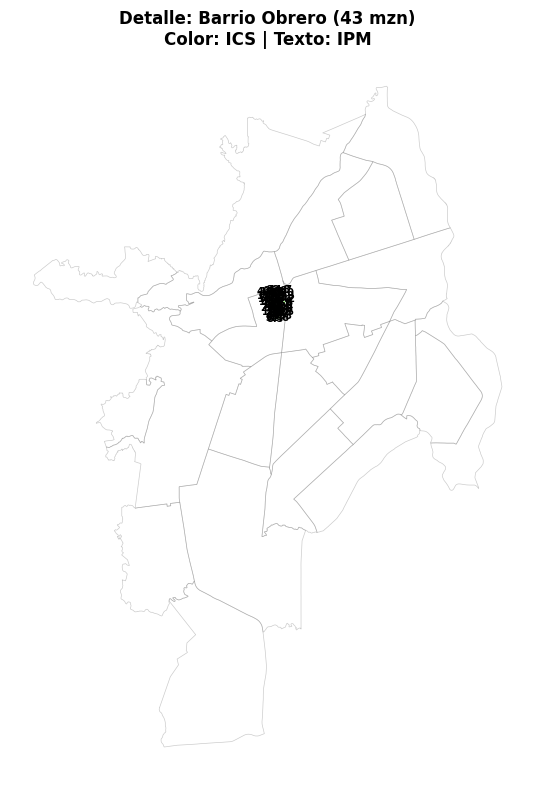

Roosevelt: 34 manzanas mapeadas


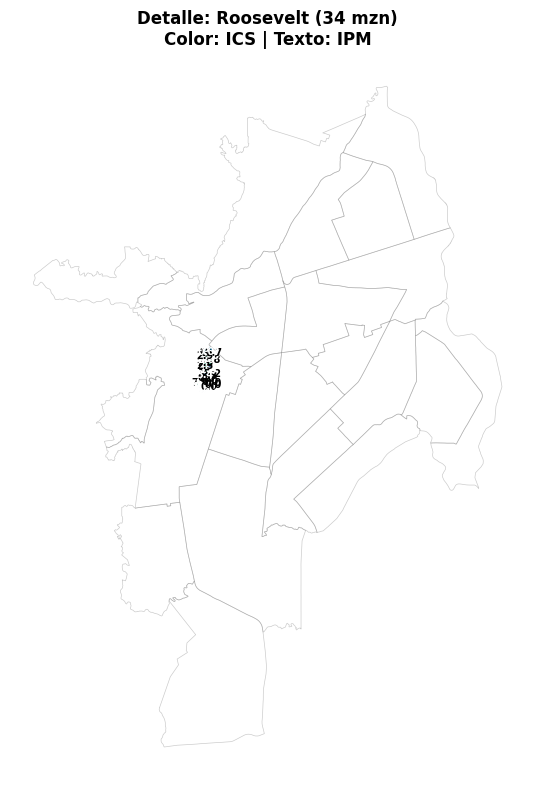

Ciudad De Cali T1: 40 manzanas mapeadas


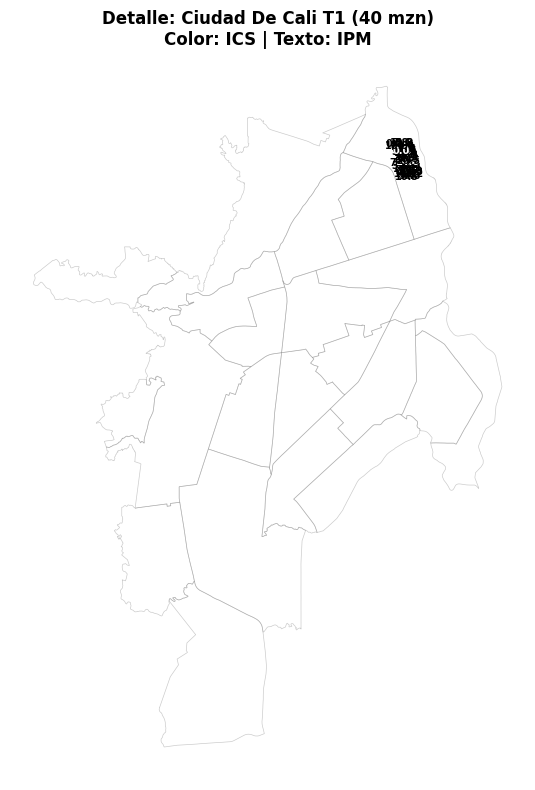

Ciudad De Cali T2: 43 manzanas mapeadas


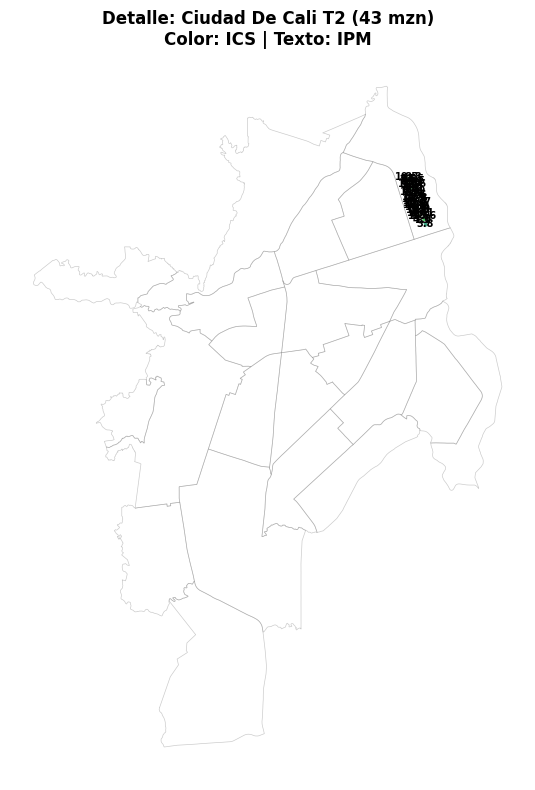

Ciudad De Cali T3: 83 manzanas mapeadas


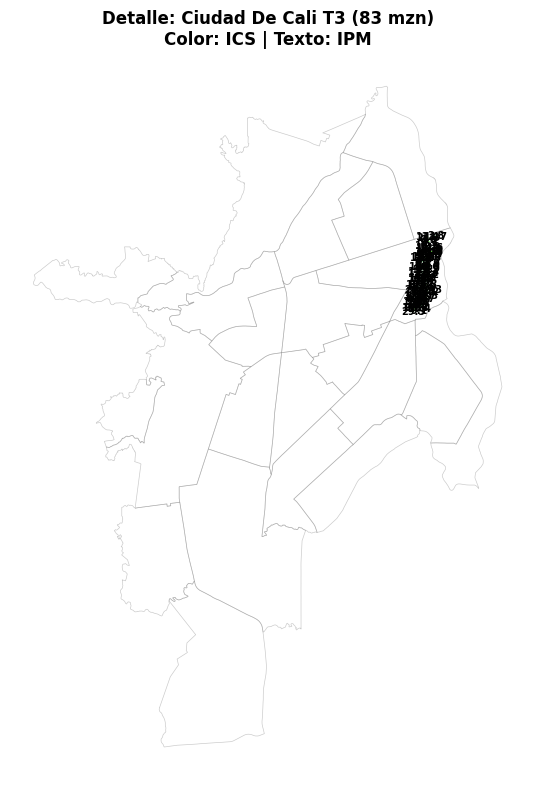

Ciudad De Cali T4: 111 manzanas mapeadas


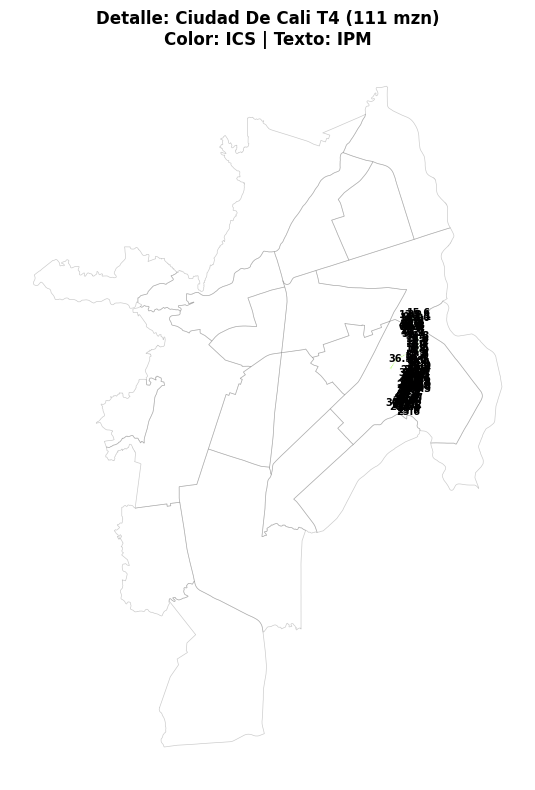

Ciudad De Cali T5: 71 manzanas mapeadas


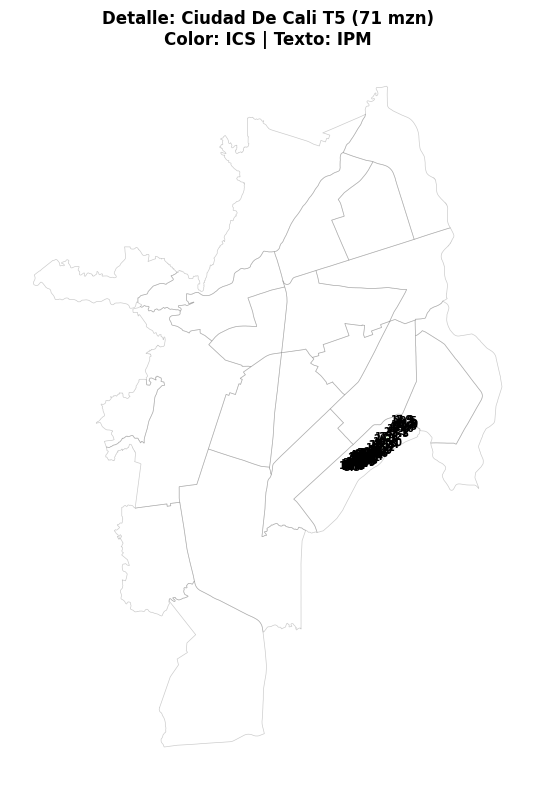

Ciudad De Cali T6: 104 manzanas mapeadas


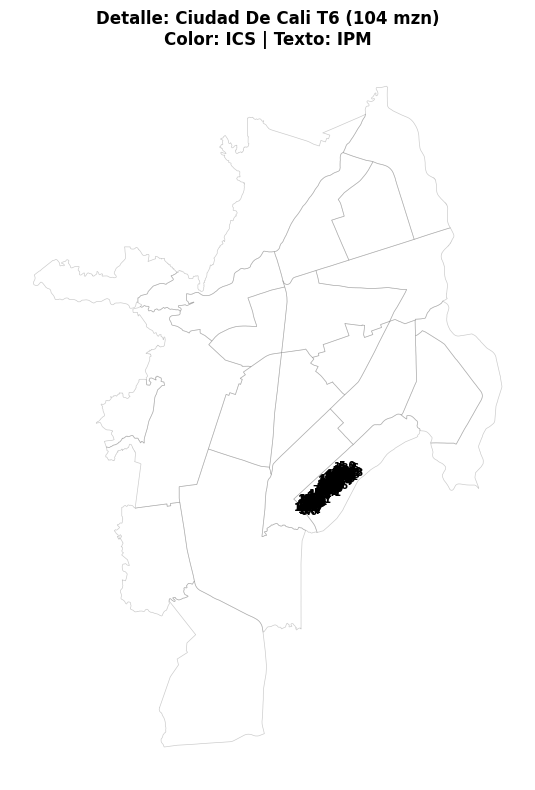

Ciudad De Cali T7: 74 manzanas mapeadas


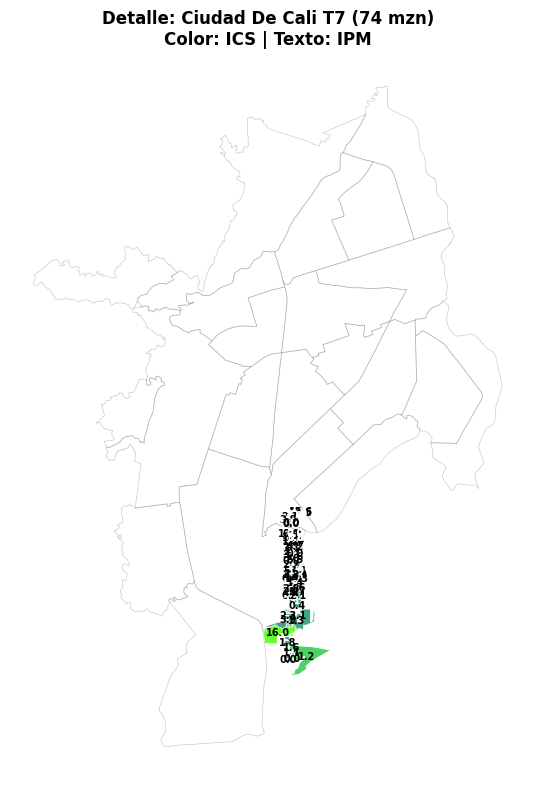

Ciudad De Cali T8: 4 manzanas mapeadas


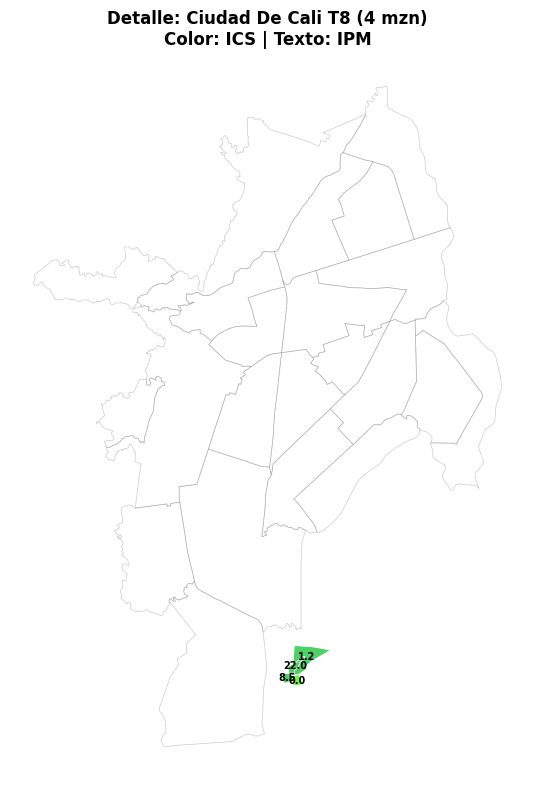

In [113]:
# @title 28. Mapas Individuales por Zona - IPM y Clasificación ICS
for name in ZONAS_VISIBLES:
    if name in gdf_ics_zonas:
        m_data = preparar_mapa(gdf_ics_zonas[name], gdf_ipm_zonas[name], name.replace('_',' ').title())
        if m_data is not None:
            fig, ax = plt.subplots(1, 1, figsize=(10, 8))
            gdf_plot = gpd.GeoDataFrame(m_data, crs=gdf_ics.crs)
            
            # Fondo: Comunas circundantes
            gdf_comunas_proj.boundary.plot(ax=ax, color='gray', linewidth=0.5, alpha=0.4)
            
            # Capa ICS: Colores de categoría
            gdf_plot.plot(ax=ax, color=gdf_plot['color_ics'], edgecolor='white', linewidth=0.6)
            
            # Etiquetas IPM con contraste adaptativo
            for _, row in gdf_plot.iterrows():
                c = row.geometry.centroid
                ax.text(c.x, c.y, f"{row['ipm']:.1f}", fontsize=7, ha='center', va='center',
                         color='white' if row['ics'] > 45 else 'black', fontweight='bold')
            
            ax.set_title(f"Detalle: {name.replace('_',' ').title()} ({len(gdf_plot)} mzn)\nColor: ICS | Texto: IPM", 
                         fontsize=12, fontweight='bold')
            ax.set_axis_off()
            plt.tight_layout()
            plt.show()


## Análisis comparativo: Zonas de interés (ICS e IPM)


In [114]:
# @title 27. Filtrar ICS e IPM para todas las zonas (Dinámico)
gdf_ics_zonas = {}
gdf_ipm_zonas = {}

for name in gdf_itt_proj.keys():
    col_name = f'en_{name.lower()}'
    # Filtrar ICS
    gdf_ics_zonas[name] = gdf_ics[gdf_ics[col_name]].copy()
    # Filtrar IPM
    gdf_ipm_zonas[name] = gdf_ipm[gdf_ipm[col_name]].copy()
    
    print(f'Filtrados {name:.<25} ICS: {len(gdf_ics_zonas[name])} | IPM: {len(gdf_ipm_zonas[name])}')

# Definir variables específicas para compatibilidad con mapeo antiguo
gdf_obrero_filt = gdf_ics_zonas.get('Barrio_Obrero')
gdf_roosevelt_filt = gdf_ics_zonas.get('Roosevelt')
gdf_ipm_obrero = gdf_ipm_zonas.get('Barrio_Obrero')
gdf_ipm_roosevelt = gdf_ipm_zonas.get('Roosevelt')



Filtrados ciudad_de_cali_T5........ ICS: 83 | IPM: 83
Filtrados ciudad_de_cali_T3........ ICS: 99 | IPM: 99
Filtrados ciudad_de_cali_T8........ ICS: 5 | IPM: 5
Filtrados Barrio_Obrero............ ICS: 45 | IPM: 45
Filtrados Roosevelt................ ICS: 41 | IPM: 41
Filtrados ciudad_de_cali_T6........ ICS: 117 | IPM: 117
Filtrados ciudad_de_cali_T1........ ICS: 44 | IPM: 44
Filtrados ciudad_de_cali_T7........ ICS: 93 | IPM: 93
Filtrados ciudad_de_cali_T4........ ICS: 122 | IPM: 122
Filtrados ciudad_de_cali_T2........ ICS: 45 | IPM: 45
Filtrados Oriente.................. ICS: 1092 | IPM: 1092


In [115]:
# @title 28. Generar mapas comparativos por zona (Dinámico)
mapa_obrero = preparar_mapa(gdf_obrero_filt, gdf_ipm_obrero, 'Barrio Obrero')
mapa_roosevelt = preparar_mapa(gdf_roosevelt_filt, gdf_ipm_roosevelt, 'Roosevelt')

# AQUÍ PUEDES AGREGAR CUALQUIER OTRA ZONA (Ej. tramo T4)
# mapa_t4 = preparar_mapa(gdf_ics_zonas.get('ciudad_de_cali_T4'), 
#                         gdf_ipm_zonas.get('ciudad_de_cali_T4'), 'Tramo T4')



Barrio Obrero: 43 manzanas mapeadas
Roosevelt: 34 manzanas mapeadas


In [116]:
# @title 29. Estadísticas comparativas ICS, IPM global y vars
print('=== COMPARATIVA ICS ===')
comp_ics = pd.DataFrame({
    'Ciudad': gdf_ics['ics'].describe(),
    'Barrio Obrero': gdf_obrero_filt['ics'].describe() if len(gdf_obrero_filt) > 0 else {},
    'Roosevelt': gdf_roosevelt_filt['ics'].describe() if len(gdf_roosevelt_filt) > 0 else {}
}).round(2)
display(comp_ics)

print('\n=== COMPARATIVA IPM global ===')
comp_ipm = pd.DataFrame({
    'Ciudad': gdf_ipm['ipm'].describe(),
    'Barrio Obrero': gdf_ipm_obrero['ipm'].describe() if len(gdf_ipm_obrero) > 0 else {},
    'Roosevelt': gdf_ipm_roosevelt['ipm'].describe() if len(gdf_ipm_roosevelt) > 0 else {}
}).round(2)
display(comp_ipm)

print('\n=== COMPARATIVA variables IPM (promedio) ===')
comp_vars = pd.DataFrame({
    'Barrio Obrero': means_obrero if len(gdf_vars_obrero) > 0 else pd.Series(dtype=float),
    'Roosevelt': means_roosevelt if len(gdf_vars_roosevelt) > 0 else pd.Series(dtype=float)
}).round(2)
if len(comp_vars) > 0:
    comp_vars.index = [diccionario.get(v.replace('_val',''), v) for v in comp_vars.index]
    comp_vars['Diferencia (Roo - BO)'] = (comp_vars['Roosevelt'] - comp_vars['Barrio Obrero']).round(2)
    display(comp_vars.style.background_gradient(cmap='RdYlGn_r', axis=None))
else:
    print('Sin datos de variables IPM por zona')


=== COMPARATIVA ICS ===


,Ciudad,Barrio Obrero,Roosevelt
count,15658.00,45.00,41.00
mean,29.80,25.40,39.71
std,17.18,7.17,20.23
min,0.00,0.00,0.00
25%,21.58,23.38,37.75
50%,29.55,26.29,44.72
75%,39.00,28.55,51.31
max,335.05,35.69,74.53



=== COMPARATIVA IPM global ===


,Ciudad,Barrio Obrero,Roosevelt
count,15658.00,45.00,41.00
mean,11.69,13.58,3.85
std,14.73,10.82,5.32
min,0.00,0.00,0.00
25%,0.00,3.60,0.00
50%,7.20,12.00,2.50
75%,17.10,22.20,7.10
max,100.00,40.00,25.00



=== COMPARATIVA variables IPM (promedio) ===


,Barrio Obrero,Roosevelt,Diferencia (Roo - BO)
Sin acceso a agua mejorada,4.750000,2.260000,-2.490000
Analfabetismo,9.360000,9.480000,0.120000
Sin aseguramiento en salud,19.190000,22.050000,2.860000
Bajo logro educativo,54.190000,17.580000,-36.610000
Dependencia económica,27.050000,19.090000,-7.960000
Eliminación inadecuada de excretas,5.160000,2.300000,-2.860000
Hacinamiento crítico,15.070000,6.050000,-9.020000
Inasistencia escolar,10.670000,4.890000,-5.780000
Barreras primera infancia,8.030000,7.080000,-0.950000
Informalidad,92.730000,74.360000,-18.370000


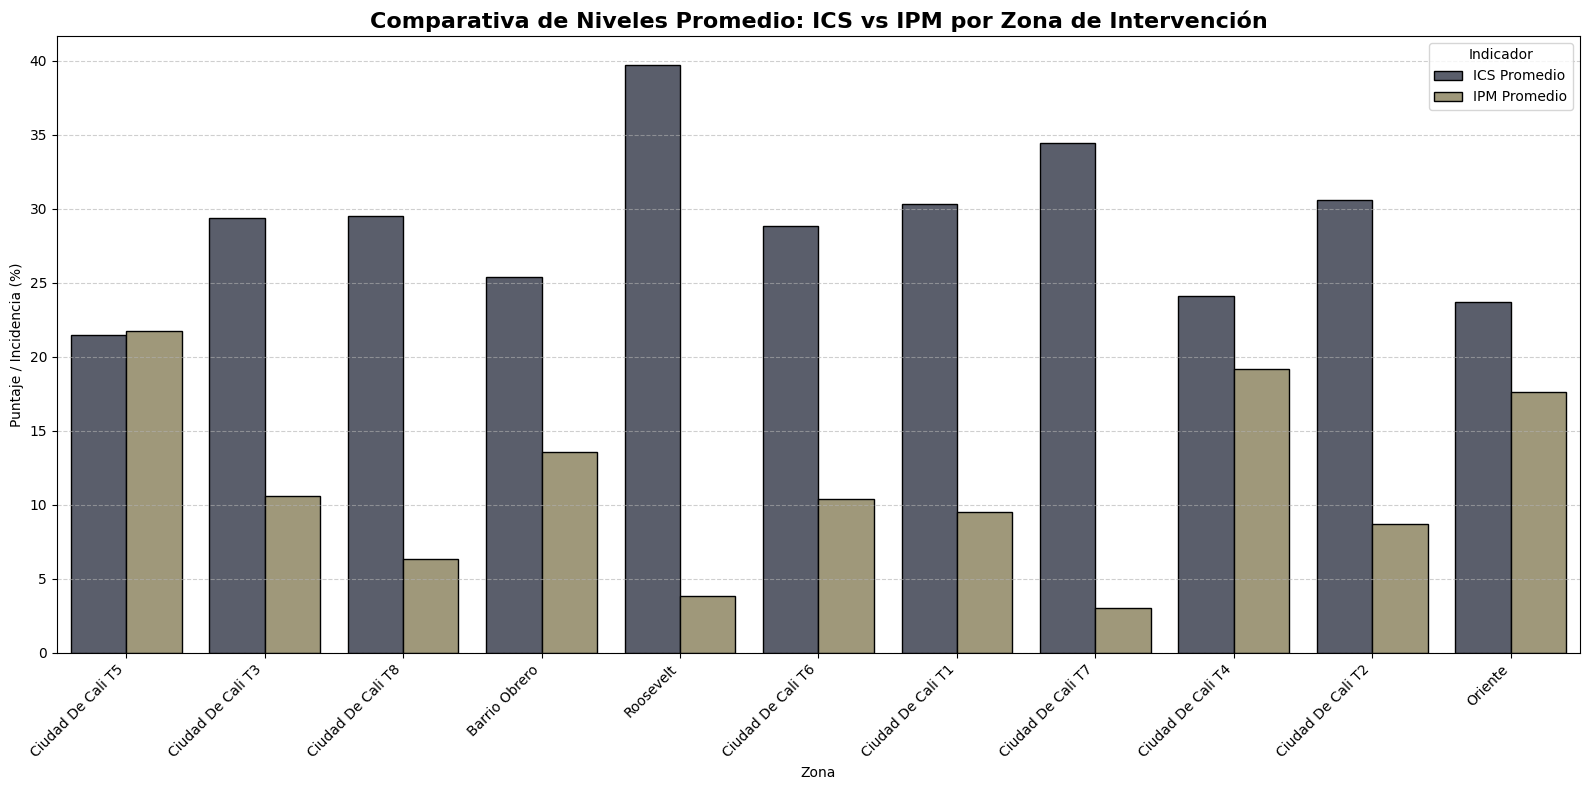

In [117]:
# @title 30. Comparativa ICS e IPM por Zona - Gráficos de Barras (Accesible)
import seaborn as sns

# Preparar datos para barplot agrupado
stats_list = []
for name, gdf_filt in gdf_ics_zonas.items():
    if len(gdf_filt) > 0:
        stats_list.append({'Zona': name.replace('_',' ').title(), 'Valor': gdf_filt['ics'].mean(), 'Indicador': 'ICS Promedio'})
for name, gdf_filt in gdf_ipm_zonas.items():
    if len(gdf_filt) > 0:
        stats_list.append({'Zona': name.replace('_',' ').title(), 'Valor': gdf_filt['ipm'].mean(), 'Indicador': 'IPM Promedio'})

df_stats_plot = pd.DataFrame(stats_list)

plt.figure(figsize=(16, 8))
sns.barplot(data=df_stats_plot, x='Zona', y='Valor', hue='Indicador', palette='cividis', edgecolor='black')

plt.title('Comparativa de Niveles Promedio: ICS vs IPM por Zona de Intervención', fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Puntaje / Incidencia (%)')
plt.legend(title='Indicador')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


## Relación ICS vs IPM por zona de interés


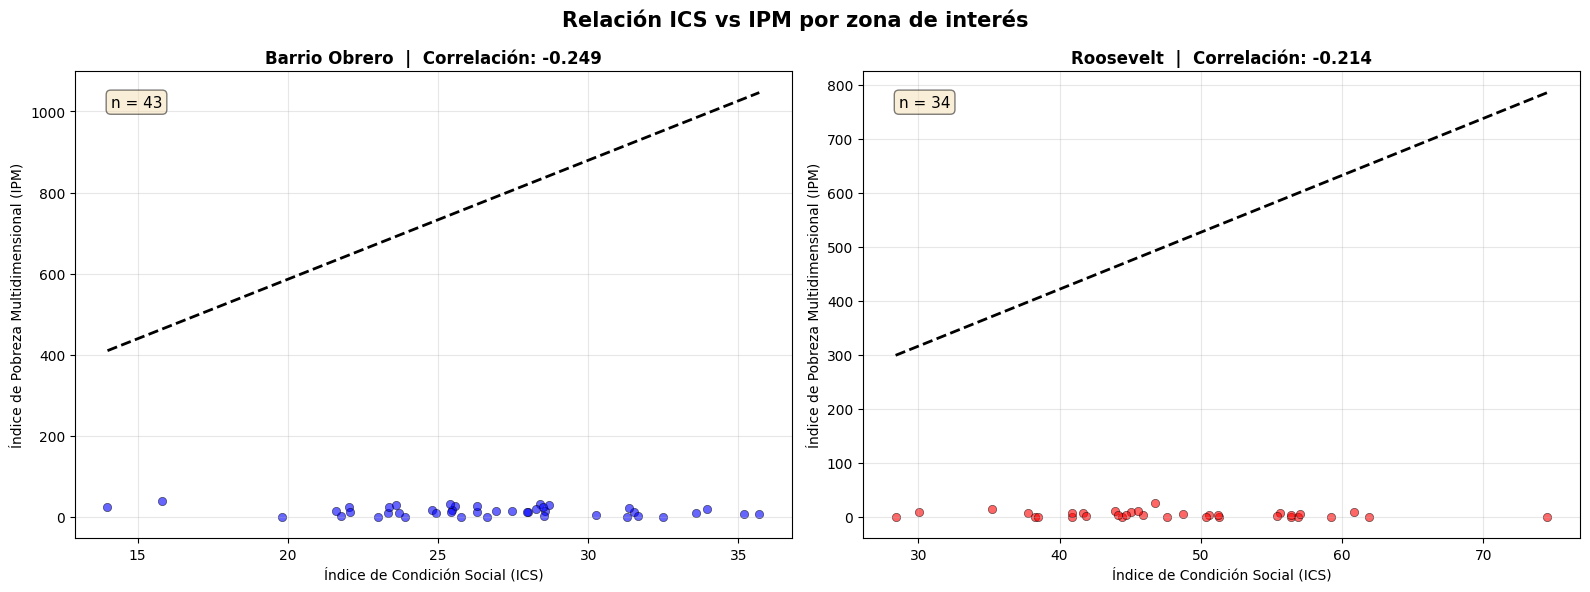

In [118]:
# @title 31. Relación ICS vs IPM - scatter por zona
if len(gdf_obrero_filt) > 0 and len(gdf_ipm_obrero) > 0:
    merge_obrero = gdf_obrero_filt.merge(
        gdf_ipm_obrero[['cod_dane', 'ipm']], left_on='cod_dane_a', right_on='cod_dane', how='inner')
if len(gdf_roosevelt_filt) > 0 and len(gdf_ipm_roosevelt) > 0:
    merge_roosevelt = gdf_roosevelt_filt.merge(
        gdf_ipm_roosevelt[['cod_dane', 'ipm']], left_on='cod_dane_a', right_on='cod_dane', how='inner')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

for ax, data, nombre, color in [
    (ax1, merge_obrero if len(gdf_obrero_filt) > 0 else None, 'Barrio Obrero', 'blue'),
    (ax2, merge_roosevelt if len(gdf_roosevelt_filt) > 0 else None, 'Roosevelt', 'red')
]:
    if data is not None and len(data) > 0:
        x, y = data['ics'], data['ipm']
        ax.scatter(x, y, alpha=0.6, color=color, edgecolors='black', linewidth=0.5)
        coeffs = np.polyfit(x, y, 1)
        x_line = np.linspace(x.min(), x.max(), 100)
        ax.plot(x_line, coeffs[0] + coeffs[1] * x_line, color='black', linewidth=2, linestyle='--')
        corr = x.corr(y)
        ax.set_title(f'{nombre}  |  Correlación: {corr:.3f}', fontweight='bold')
        ax.text(0.05, 0.95, f'n = {len(data)}', transform=ax.transAxes,
                fontsize=11, va='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    else:
        ax.text(0.5, 0.5, 'Sin datos', ha='center', va='center', fontsize=14)
    ax.set_xlabel('Índice de Condición Social (ICS)')
    ax.set_ylabel('Índice de Pobreza Multidimensional (IPM)')
    ax.grid(alpha=0.3)

plt.suptitle('Relación ICS vs IPM por zona de interés', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


## Cálculo de Áreas y Análisis de Tramos (Ciudad de Cali)

Implementación de la lógica de proyección a **MAGNA-SIRGAS / Origen Nacional (EPSG:9377)** para el cálculo preciso de superficies y consolidación de los 8 tramos del corredor.


In [119]:
# @title 32. Cálculo de Áreas Métricas (EPSG:9377)
CRS_PROYECTADO = "EPSG:9377"

areas_report = []
for name, gdf in gdf_itt.items():
    gdf_proj = gdf.to_crs(CRS_PROYECTADO)
    area_m2 = gdf_proj.area.sum()
    area_ha = area_m2 / 10000
    areas_report.append({
        'Zona/Tramo': name.replace('_', ' ').title(),
        'Área (m2)': area_m2,
        'Área (Ha)': area_ha
    })

# Consolidado Ciudad de Cali (8 tramos)
cc_tramos = [gdf for name, gdf in gdf_itt.items() if 'ciudad_de_cali' in name.lower()]
if cc_tramos:
    gdf_cc_total = pd.concat(cc_tramos)
    gdf_cc_proj = gdf_cc_total.to_crs(CRS_PROYECTADO)
    area_cc_m2 = gdf_cc_proj.area.sum()
    areas_report.append({
        'Zona/Tramo': 'Ciudad De Cali (Total)',
        'Área (m2)': area_cc_m2,
        'Área (Ha)': area_cc_m2 / 10000
    })

df_areas = pd.DataFrame(areas_report).round(2).sort_values(by='Área (Ha)', ascending=False)
print('--- Resumen de Áreas Territoriales (Magna-SIRGAS) ---')
display(df_areas)

# Exportar a outputs
OUTPUT_DIR = os.path.join(REPO_DIR if os.path.exists(REPO_DIR) else '.', 'indice_Pobreza', 'outputs')
if not os.path.exists(OUTPUT_DIR): os.makedirs(OUTPUT_DIR)
df_areas.to_csv(os.path.join(OUTPUT_DIR, 'resumen_areas_notebook.csv'), index=False)


--- Resumen de Áreas Territoriales (Magna-SIRGAS) ---


,Zona/Tramo,Área (m2),Área (Ha)
10,Oriente,5515022.83,551.50
11,Ciudad De Cali (Total),4339666.10,433.97
7,Ciudad De Cali T7,1118667.99,111.87
1,Ciudad De Cali T3,727930.26,72.79
8,Ciudad De Cali T4,621340.12,62.13
2,Ciudad De Cali T8,474128.59,47.41
4,Roosevelt,429175.57,42.92
5,Ciudad De Cali T6,396898.72,39.69
3,Barrio Obrero,377466.70,37.75
9,Ciudad De Cali T2,371706.73,37.17


In [120]:
# @title 33. Estadísticas de Severidad por Tramo (IPM > 0)
def get_severity(gdf_poly, gdf_ipm_full):
    # Spatial join usando centroides para evitar duplicados en bordes
    gdf_temp = gdf_ipm_full.copy()
    gdf_temp['geometry'] = gdf_temp.centroid
    joined = gpd.sjoin(gdf_temp, gdf_poly.to_crs(gdf_temp.crs), how='inner', predicate='within')
    
    # Filtrar severidad (IPM > 0)
    filt = joined[joined['ipm'] > 0]
    if len(filt) == 0: return None
    
    return {
        'manzanas': len(filt),
        'ipm_promedio': filt['ipm'].mean()
    }

severity_report = []
for name, gdf in gdf_itt.items():
    res = get_severity(gdf, gdf_ipm)
    if res:
        severity_report.append({
            'Zona': name.replace('_', ' ').title(),
            'Manzanas (IPM>0)': res['manzanas'],
            'IPM Severidad': res['ipm_promedio']
        })

df_sev = pd.DataFrame(severity_report).round(2).sort_values(by='IPM Severidad', ascending=False)
print('--- Perfil de Severidad por Territorio ---')
display(df_sev)


/tmp/ipykernel_31916/279688037.py:5: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_temp['geometry'] = gdf_temp.centroid
/tmp/ipykernel_31916/279688037.py:5: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_temp['geometry'] = gdf_temp.centroid
/tmp/ipykernel_31916/279688037.py:5: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_temp['geometry'] = gdf_temp.centroid
/tmp/ipykernel_31916/279688037.py:5: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before 

--- Perfil de Severidad por Territorio ---


/tmp/ipykernel_31916/279688037.py:5: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_temp['geometry'] = gdf_temp.centroid


,Zona,Manzanas (IPM>0),IPM Severidad
0,Ciudad De Cali T5,60,23.28
8,Ciudad De Cali T4,98,22.17
2,Ciudad De Cali T8,1,22.00
10,Oriente,901,21.00
3,Barrio Obrero,36,16.98
5,Ciudad De Cali T6,82,13.03
6,Ciudad De Cali T1,34,11.94
1,Ciudad De Cali T3,76,11.81
9,Ciudad De Cali T2,41,9.17
4,Roosevelt,21,7.51
